<a href="https://colab.research.google.com/github/Kavyasree2006/Hospital_Bed_Occupancy_Forecaster_MODEL/blob/main/Hospital_Bed_Occupancy_Forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
uploaded = files.upload()


Saving MOCK_DATA (7).csv to MOCK_DATA (7).csv
Saving MOCK_DATA (6).csv to MOCK_DATA (6).csv
Saving MOCK_DATA (5).csv to MOCK_DATA (5).csv
Saving MOCK_DATA (4).csv to MOCK_DATA (4).csv
Saving MOCK_DATA (3).csv to MOCK_DATA (3).csv
Saving MOCK_DATA (2).csv to MOCK_DATA (2).csv
Saving MOCK_DATA (1).csv to MOCK_DATA (1).csv


In [ ]:
file_names = list(uploaded.keys())

print(file_names)

['MOCK_DATA (7).csv', 'MOCK_DATA (6).csv', 'MOCK_DATA (5).csv', 'MOCK_DATA (4).csv', 'MOCK_DATA (3).csv', 'MOCK_DATA (2).csv', 'MOCK_DATA (1).csv']


In [ ]:
df = pd.concat(
    [pd.read_csv(file) for file in file_names],
    ignore_index=True
)

df.head()

,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay
0,2036-06-05,Thursday,June,Summer,281,207,73.67,75,75,40,3,Surgery,No,No,99,7.8
1,2036-06-06,Friday,June,Summer,349,258,73.93,85,92,38,12,Emergency,No,No,86,1.8
2,2036-06-07,Saturday,June,Summer,239,169,70.71,102,100,54,8,General Medicine,No,No,86,6.0
3,2036-06-08,Sunday,June,Summer,331,254,76.74,49,39,16,2,Orthopedics,Yes,No,84,5.6
4,2036-06-09,Monday,June,Summer,384,334,86.98,72,72,33,7,Cardiology,No,No,87,3.0


In [ ]:
print("Rows and columns:", df.shape)

Rows and columns: (7000, 16)


In [ ]:
df.columns

Index(['Date', 'Day of week', 'Month', 'Season', 'Total Hospital Beds',
       'Beds Occupied', 'Occupancy Rate (%)', 'Daily Admissions',
       'Daily Discharges', 'Emergency Admissions', 'ICU Admissions',
       'Department', 'Public Holiday Indicator', 'Special Event Indicator',
       'Staff Availability', 'Average Length of Stay'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Date,0
Day of week,0
Month,0
Season,0
Total Hospital Beds,0
Beds Occupied,0
Occupancy Rate (%),0
Daily Admissions,0
Daily Discharges,0
Emergency Admissions,0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      7000 non-null   datetime64[ns]
 1   Day of week               7000 non-null   object        
 2   Month                     7000 non-null   object        
 3   Season                    7000 non-null   object        
 4   Total Hospital Beds       7000 non-null   int64         
 5   Beds Occupied             7000 non-null   int64         
 6   Occupancy Rate (%)        7000 non-null   float64       
 7   Daily Admissions          7000 non-null   int64         
 8   Daily Discharges          7000 non-null   int64         
 9   Emergency Admissions      7000 non-null   int64         
 10  ICU Admissions            7000 non-null   int64         
 11  Department                7000 non-null   object        
 12  Public Holiday Indic

In [ ]:
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay
0,2020-01-01,Wednesday,January,Winter,317,215,67.82,92,96,29,7,Cardiology,No,No,87,4.6
1,2020-01-02,Thursday,January,Winter,444,359,80.86,58,68,28,2,Maternity,No,No,83,3.0
2,2020-01-03,Friday,January,Winter,384,291,75.78,97,104,24,12,Cardiology,No,No,85,5.4
3,2020-01-04,Saturday,January,Winter,272,212,77.94,72,71,31,8,ICU,No,No,91,10.6
4,2020-01-05,Sunday,January,Winter,305,283,92.79,65,70,18,6,Cardiology,No,No,84,4.5


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
df["Year"] = df["Date"].dt.year

df[["Date", "Year"]].head()

,Date,Year
0,2020-01-01,2020
1,2020-01-02,2020
2,2020-01-03,2020
3,2020-01-04,2020
4,2020-01-05,2020


In [ ]:
df["net_bed_change"] = df["Daily Admissions"] - df["Daily Discharges"]

df[["Daily Admissions", "Daily Discharges", "net_bed_change"]].head()

,Daily Admissions,Daily Discharges,net_bed_change
0,92,96,-4
1,58,68,-10
2,97,104,-7
3,72,71,1
4,65,70,-5


In [ ]:
print("Rows and columns:", df.shape)

Rows and columns: (7000, 18)


In [ ]:
df.to_csv("hospital_occupancy_7000.csv", index=False)

In [ ]:
files.download("hospital_occupancy_7000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Import Dataset Using Python And Pandas

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()

Saving hospital_occupancy_7000 (1).csv to hospital_occupancy_7000 (1).csv


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change
0,2020-01-01,Wednesday,January,Winter,317,215,67.82,92,96,29,7,Cardiology,No,No,87,4.6,2020,-4
1,2020-01-02,Thursday,January,Winter,444,359,80.86,58,68,28,2,Maternity,No,No,83,3.0,2020,-10
2,2020-01-03,Friday,January,Winter,384,291,75.78,97,104,24,12,Cardiology,No,No,85,5.4,2020,-7
3,2020-01-04,Saturday,January,Winter,272,212,77.94,72,71,31,8,ICU,No,No,91,10.6,2020,1
4,2020-01-05,Sunday,January,Winter,305,283,92.79,65,70,18,6,Cardiology,No,No,84,4.5,2020,-5


In [ ]:
# 2. Initial Data Inspection

# Number of rows and columns
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns)

# First 5 rows
display(df.head())

# Last 5 rows
display(df.tail())

# Data types and non-null counts
df.info()

# Summary statistics
display(df.describe())

Dataset shape: (7000, 18)

Column names:
Index(['Date', 'Day of week', 'Month', 'Season', 'Total Hospital Beds',
       'Beds Occupied', 'Occupancy Rate (%)', 'Daily Admissions',
       'Daily Discharges', 'Emergency Admissions', 'ICU Admissions',
       'Department', 'Public Holiday Indicator', 'Special Event Indicator',
       'Staff Availability', 'Average Length of Stay', 'Year',
       'net_bed_change'],
      dtype='object')


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change
0,2020-01-01,Wednesday,January,Winter,317,215,67.82,92,96,29,7,Cardiology,No,No,87,4.6,2020,-4
1,2020-01-02,Thursday,January,Winter,444,359,80.86,58,68,28,2,Maternity,No,No,83,3.0,2020,-10
2,2020-01-03,Friday,January,Winter,384,291,75.78,97,104,24,12,Cardiology,No,No,85,5.4,2020,-7
3,2020-01-04,Saturday,January,Winter,272,212,77.94,72,71,31,8,ICU,No,No,91,10.6,2020,1
4,2020-01-05,Sunday,January,Winter,305,283,92.79,65,70,18,6,Cardiology,No,No,84,4.5,2020,-5


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change
6995,2039-02-25,Friday,February,Winter,280,204,72.86,103,89,51,16,Surgery,No,No,80,4.5,2039,14
6996,2039-02-26,Saturday,February,Winter,224,150,66.96,83,75,30,12,Maternity,No,No,87,1.5,2039,8
6997,2039-02-27,Sunday,February,Winter,185,164,88.65,88,95,47,10,General Medicine,No,No,100,3.2,2039,-7
6998,2039-02-28,Monday,February,Winter,416,324,77.88,59,46,20,5,Emergency,No,No,88,0.5,2039,13
6999,2039-03-01,Tuesday,March,Spring,327,291,88.99,51,37,12,3,Pediatrics,No,Yes,77,6.9,2039,14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      7000 non-null   object 
 1   Day of week               7000 non-null   object 
 2   Month                     7000 non-null   object 
 3   Season                    7000 non-null   object 
 4   Total Hospital Beds       7000 non-null   int64  
 5   Beds Occupied             7000 non-null   int64  
 6   Occupancy Rate (%)        7000 non-null   float64
 7   Daily Admissions          7000 non-null   int64  
 8   Daily Discharges          7000 non-null   int64  
 9   Emergency Admissions      7000 non-null   int64  
 10  ICU Admissions            7000 non-null   int64  
 11  Department                7000 non-null   object 
 12  Public Holiday Indicator  7000 non-null   object 
 13  Special Event Indicator   7000 non-null   object 
 14  Staff Av

,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Staff Availability,Average Length of Stay,Year,net_bed_change
count,7000.000000,7000.00000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,316.688000,253.00400,79.903984,69.814857,67.214286,27.670000,7.517857,88.628286,4.931286,2029.085000,2.600571
std,78.056193,68.61217,8.901716,26.359479,27.284006,12.605592,4.307209,7.394414,2.744902,5.531662,7.547660
min,180.000000,117.00000,64.480000,25.000000,10.000000,6.000000,1.000000,60.000000,0.500000,2020.000000,-10.000000
25%,249.000000,197.00000,71.990000,47.000000,44.000000,18.000000,4.000000,84.000000,2.800000,2024.000000,-4.000000
50%,318.000000,251.00000,79.950000,70.000000,67.000000,26.000000,7.000000,89.000000,4.500000,2029.000000,3.000000
75%,384.000000,304.00000,87.772500,93.000000,90.000000,36.000000,10.000000,94.000000,6.500000,2034.000000,9.000000
max,450.000000,426.00000,95.000000,115.000000,125.000000,63.000000,20.000000,100.000000,14.000000,2039.000000,15.000000


In [ ]:
# 3. Convert Date Column

df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      7000 non-null   datetime64[ns]
 1   Day of week               7000 non-null   object        
 2   Month                     7000 non-null   object        
 3   Season                    7000 non-null   object        
 4   Total Hospital Beds       7000 non-null   int64         
 5   Beds Occupied             7000 non-null   int64         
 6   Occupancy Rate (%)        7000 non-null   float64       
 7   Daily Admissions          7000 non-null   int64         
 8   Daily Discharges          7000 non-null   int64         
 9   Emergency Admissions      7000 non-null   int64         
 10  ICU Admissions            7000 non-null   int64         
 11  Department                7000 non-null   object        
 12  Public Holiday Indic

In [ ]:
# 4. Check Missing Values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Date                        0
Day of week                 0
Month                       0
Season                      0
Total Hospital Beds         0
Beds Occupied               0
Occupancy Rate (%)          0
Daily Admissions            0
Daily Discharges            0
Emergency Admissions        0
ICU Admissions              0
Department                  0
Public Holiday Indicator    0
Special Event Indicator     0
Staff Availability          0
Average Length of Stay      0
Year                        0
net_bed_change              0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

display(missing_report)

,Missing Values,Missing Percentage
Date,0,0.0
Day of week,0,0.0
Month,0,0.0
Season,0,0.0
Total Hospital Beds,0,0.0
Beds Occupied,0,0.0
Occupancy Rate (%),0,0.0
Daily Admissions,0,0.0
Daily Discharges,0,0.0
Emergency Admissions,0,0.0


In [ ]:
# 5. Check Duplicate Rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
duplicates = df[df.duplicated()]

display(duplicates)

,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change


In [ ]:
# 6. Check Inconsistencies

# Beds occupied should not be greater than total hospital beds
invalid_beds = df[df["Beds Occupied"] > df["Total Hospital Beds"]]

print("Invalid bed records:", len(invalid_beds))
display(invalid_beds.head())

Invalid bed records: 0


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change


In [ ]:
# Occupancy rate should be between 0 and 100
invalid_occupancy = df[
    (df["Occupancy Rate (%)"] < 0) |
    (df["Occupancy Rate (%)"] > 100)
]

print("Invalid occupancy records:", len(invalid_occupancy))
display(invalid_occupancy.head())

Invalid occupancy records: 0


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change


In [ ]:
# Daily values should not be negative
numeric_check_cols = [
    "Daily Admissions",
    "Daily Discharges",
    "Emergency Admissions",
    "ICU Admissions",
    "Staff Availability",
    "Average Length of Stay"
]

for col in numeric_check_cols:
    invalid_count = (df[col] < 0).sum()
    print(col, "negative values:", invalid_count)

Daily Admissions negative values: 0
Daily Discharges negative values: 0
Emergency Admissions negative values: 0
ICU Admissions negative values: 0
Staff Availability negative values: 0
Average Length of Stay negative values: 0


In [ ]:
# Check if calculated occupancy rate matches given occupancy rate
df["Calculated Occupancy Rate (%)"] = (
    df["Beds Occupied"] / df["Total Hospital Beds"] * 100
).round(2)

occupancy_mismatch = df[
    abs(df["Occupancy Rate (%)"] - df["Calculated Occupancy Rate (%)"]) > 0.1
]

print("Occupancy rate mismatches:", len(occupancy_mismatch))
display(occupancy_mismatch.head())

Occupancy rate mismatches: 0


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change,Calculated Occupancy Rate (%)


In [ ]:
# 7. Basic EDA

# Summary of numeric columns
display(df.describe())

,Date,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Staff Availability,Average Length of Stay,Year,net_bed_change,Calculated Occupancy Rate (%)
count,7000,7000.000000,7000.00000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,2029-07-31 12:00:00,316.688000,253.00400,79.903984,69.814857,67.214286,27.670000,7.517857,88.628286,4.931286,2029.085000,2.600571,79.903979
min,2020-01-01 00:00:00,180.000000,117.00000,64.480000,25.000000,10.000000,6.000000,1.000000,60.000000,0.500000,2020.000000,-10.000000,64.480000
25%,2024-10-15 18:00:00,249.000000,197.00000,71.990000,47.000000,44.000000,18.000000,4.000000,84.000000,2.800000,2024.000000,-4.000000,71.990000
50%,2029-07-31 12:00:00,318.000000,251.00000,79.950000,70.000000,67.000000,26.000000,7.000000,89.000000,4.500000,2029.000000,3.000000,79.950000
75%,2034-05-16 06:00:00,384.000000,304.00000,87.772500,93.000000,90.000000,36.000000,10.000000,94.000000,6.500000,2034.000000,9.000000,87.772500
max,2039-03-01 00:00:00,450.000000,426.00000,95.000000,115.000000,125.000000,63.000000,20.000000,100.000000,14.000000,2039.000000,15.000000,95.000000
std,NaN,78.056193,68.61217,8.901716,26.359479,27.284006,12.605592,4.307209,7.394414,2.744902,5.531662,7.547660,8.901717


In [ ]:
# Department counts
department_counts = df["Department"].value_counts()

display(department_counts)

,count
Department,
Orthopedics,912
Cardiology,898
Surgery,897
Maternity,872
Pediatrics,868
Emergency,858
General Medicine,854
ICU,841


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

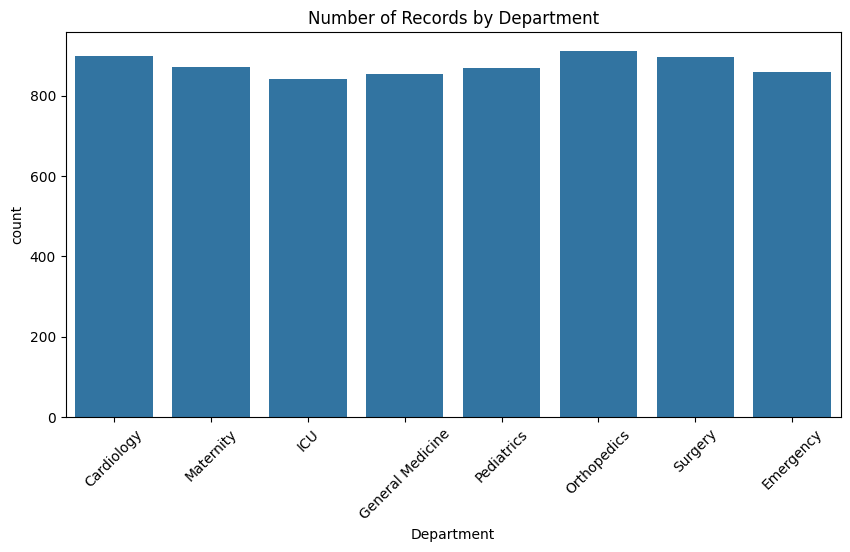

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Department")
plt.title("Number of Records by Department")
plt.xticks(rotation=45)
plt.show()

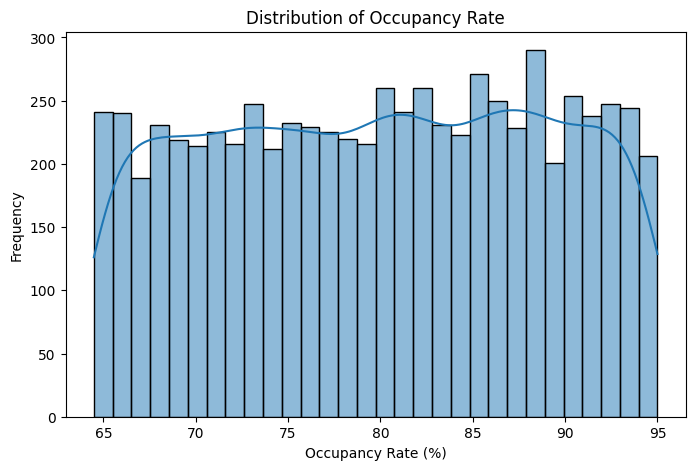

In [ ]:
# 8. Occupancy Rate Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Occupancy Rate (%)"], bins=30, kde=True)
plt.title("Distribution of Occupancy Rate")
plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# 9. Average Occupancy By Department

avg_occupancy_dept = df.groupby("Department")["Occupancy Rate (%)"].mean().sort_values(ascending=False)

display(avg_occupancy_dept)

,Occupancy Rate (%)
Department,
Maternity,80.731972
Cardiology,79.967361
General Medicine,79.929567
ICU,79.917551
Emergency,79.875909
Surgery,79.848595
Pediatrics,79.648041
Orthopedics,79.337928


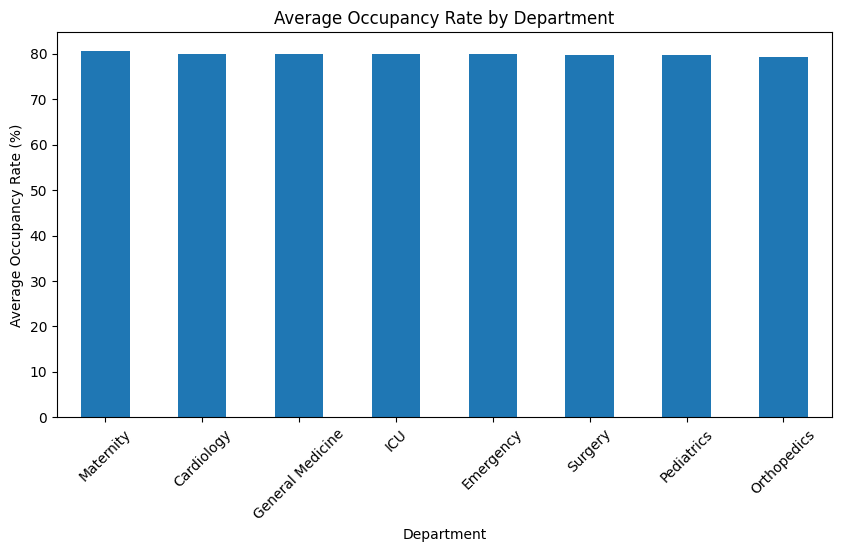

In [ ]:
plt.figure(figsize=(10, 5))
avg_occupancy_dept.plot(kind="bar")
plt.title("Average Occupancy Rate by Department")
plt.xlabel("Department")
plt.ylabel("Average Occupancy Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 10. Admissions And Discharges Trend

daily_trend = df.groupby("Date")[["Daily Admissions", "Daily Discharges"]].sum()

display(daily_trend.head())

,Daily Admissions,Daily Discharges
Date,,
2020-01-01,92,96
2020-01-02,58,68
2020-01-03,97,104
2020-01-04,72,71
2020-01-05,65,70


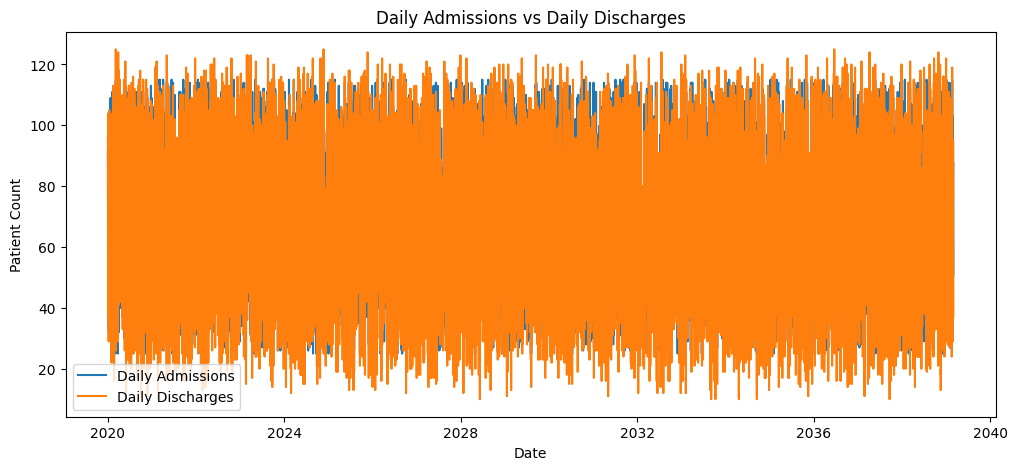

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(daily_trend.index, daily_trend["Daily Admissions"], label="Daily Admissions")
plt.plot(daily_trend.index, daily_trend["Daily Discharges"], label="Daily Discharges")
plt.title("Daily Admissions vs Daily Discharges")
plt.xlabel("Date")
plt.ylabel("Patient Count")
plt.legend()
plt.show()

In [ ]:
# 11. Net Bed Change EDA

df["net_bed_change"] = df["Daily Admissions"] - df["Daily Discharges"]

display(df[["Daily Admissions", "Daily Discharges", "net_bed_change"]].head())

,Daily Admissions,Daily Discharges,net_bed_change
0,92,96,-4
1,58,68,-10
2,97,104,-7
3,72,71,1
4,65,70,-5


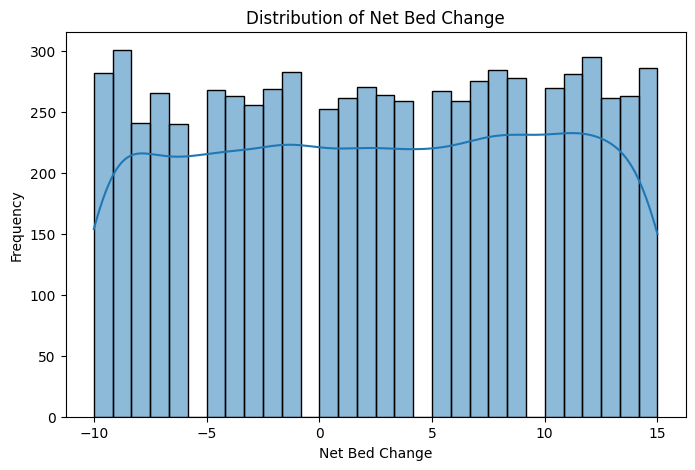

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["net_bed_change"], bins=30, kde=True)
plt.title("Distribution of Net Bed Change")
plt.xlabel("Net Bed Change")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# 12. Correlation Analysis

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

display(correlation_matrix)

,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Staff Availability,Average Length of Stay,Year,net_bed_change,Calculated Occupancy Rate (%)
Total Hospital Beds,1.000000,0.905666,-0.006065,-0.010903,-0.010852,0.003803,-0.000610,0.015406,-0.016589,-0.002415,0.001149,-0.006064
Beds Occupied,0.905666,1.000000,0.406245,-0.015910,-0.015959,-0.001098,-0.010697,0.012825,-0.019462,-0.001217,0.002123,0.406246
Occupancy Rate (%),-0.006065,0.406245,1.000000,-0.010443,-0.009907,-0.008413,-0.021374,-0.003366,-0.004199,0.004306,-0.000656,1.000000
Daily Admissions,-0.010903,-0.015910,-0.010443,1.000000,0.960989,0.847505,0.698717,0.006992,0.011789,-0.014469,0.018528,-0.010442
Daily Discharges,-0.010852,-0.015959,-0.009907,0.960989,1.000000,0.817056,0.673082,0.003803,0.007374,-0.017377,-0.258733,-0.009907
Emergency Admissions,0.003803,-0.001098,-0.008413,0.847505,0.817056,1.000000,0.602527,0.011888,0.019253,-0.001169,0.006260,-0.008413
ICU Admissions,-0.000610,-0.010697,-0.021374,0.698717,0.673082,0.602527,1.000000,0.009257,0.014979,-0.021025,0.007080,-0.021374
Staff Availability,0.015406,0.012825,-0.003366,0.006992,0.003803,0.011888,0.009257,1.000000,-0.022205,-0.005997,0.010669,-0.003367
Average Length of Stay,-0.016589,-0.019462,-0.004199,0.011789,0.007374,0.019253,0.014979,-0.022205,1.000000,0.022835,0.014513,-0.004199
Year,-0.002415,-0.001217,0.004306,-0.014469,-0.017377,-0.001169,-0.021025,-0.005997,0.022835,1.000000,0.012284,0.004306


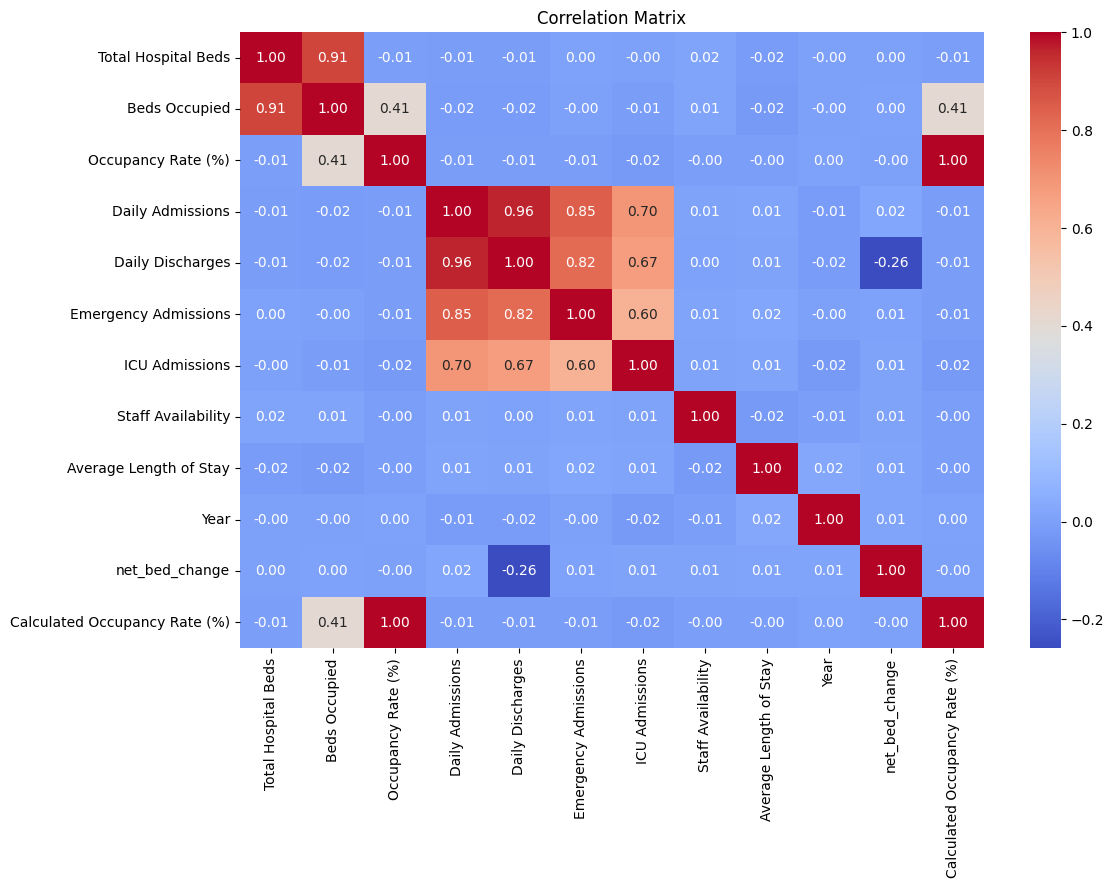

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
 # 13 Analyze Occupancy Trends Across Departments

dept_occupancy = df.groupby("Department")["Occupancy Rate (%)"].mean().sort_values(ascending=False)

display(dept_occupancy)

,Occupancy Rate (%)
Department,
Maternity,80.731972
Cardiology,79.967361
General Medicine,79.929567
ICU,79.917551
Emergency,79.875909
Surgery,79.848595
Pediatrics,79.648041
Orthopedics,79.337928


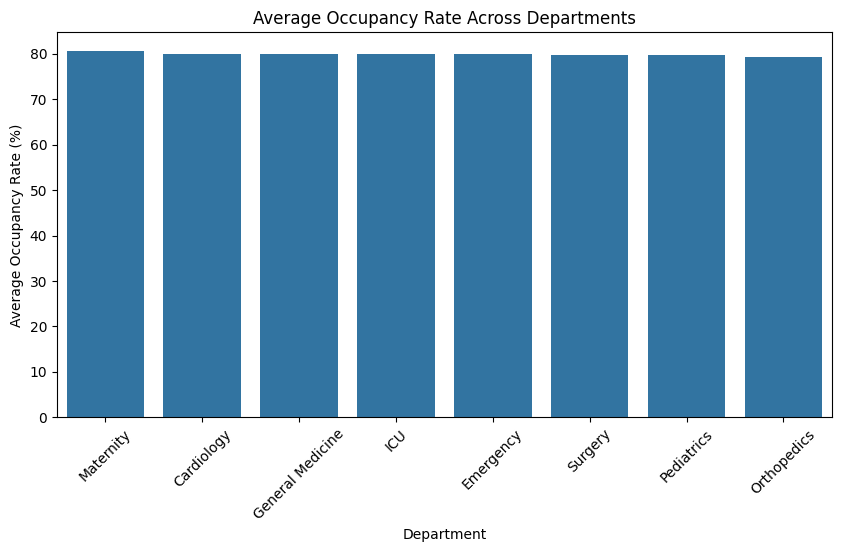

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=dept_occupancy.index,
    y=dept_occupancy.values
)
plt.title("Average Occupancy Rate Across Departments")
plt.xlabel("Department")
plt.ylabel("Average Occupancy Rate (%)")
plt.xticks(rotation=45)
plt.show()

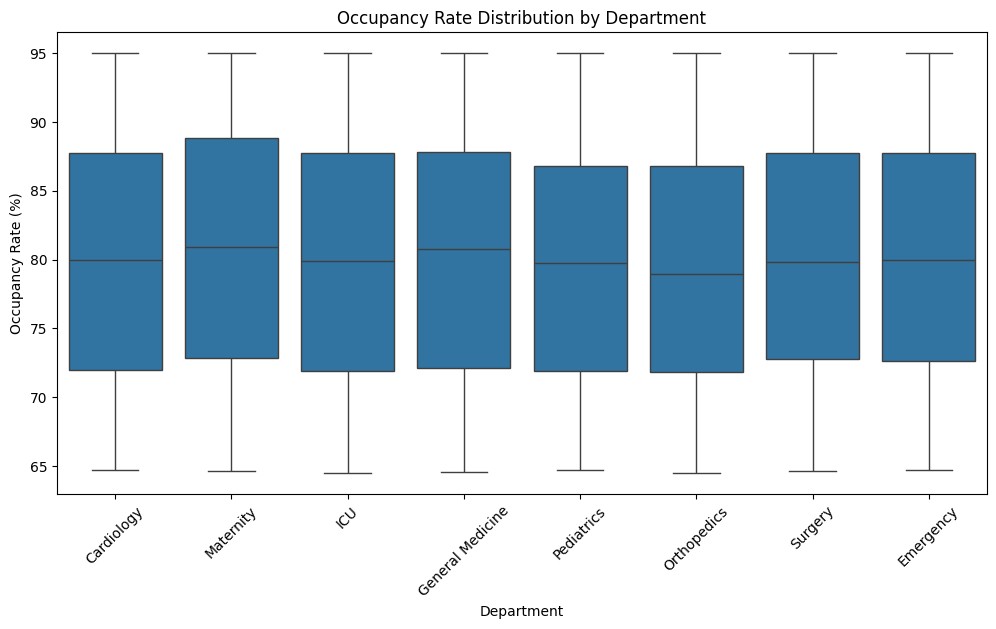

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Department",
    y="Occupancy Rate (%)"
)
plt.title("Occupancy Rate Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Occupancy Rate (%)")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2488/3834763949.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby([pd.Grouper(key="Date", freq="M"), "Department"])["Occupancy Rate (%)"]


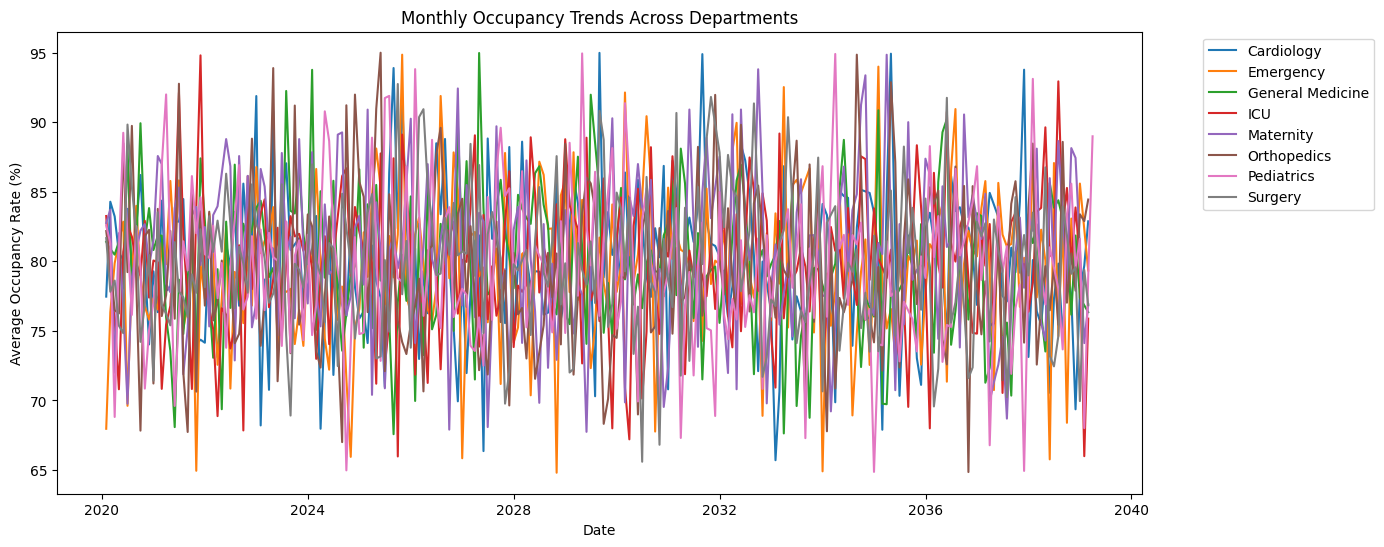

In [ ]:
# 14 Department-Wise Occupancy Trend Over Time

monthly_dept_occupancy = (
    df.groupby([pd.Grouper(key="Date", freq="M"), "Department"])["Occupancy Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_dept_occupancy,
    x="Date",
    y="Occupancy Rate (%)",
    hue="Department"
)
plt.title("Monthly Occupancy Trends Across Departments")
plt.xlabel("Date")
plt.ylabel("Average Occupancy Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
 # 15 Visualize Admission And Discharge Patterns

daily_admission_discharge = (
    df.groupby("Date")[["Daily Admissions", "Daily Discharges"]]
    .sum()
    .reset_index()
)

display(daily_admission_discharge.head())

,Date,Daily Admissions,Daily Discharges
0,2020-01-01,92,96
1,2020-01-02,58,68
2,2020-01-03,97,104
3,2020-01-04,72,71
4,2020-01-05,65,70


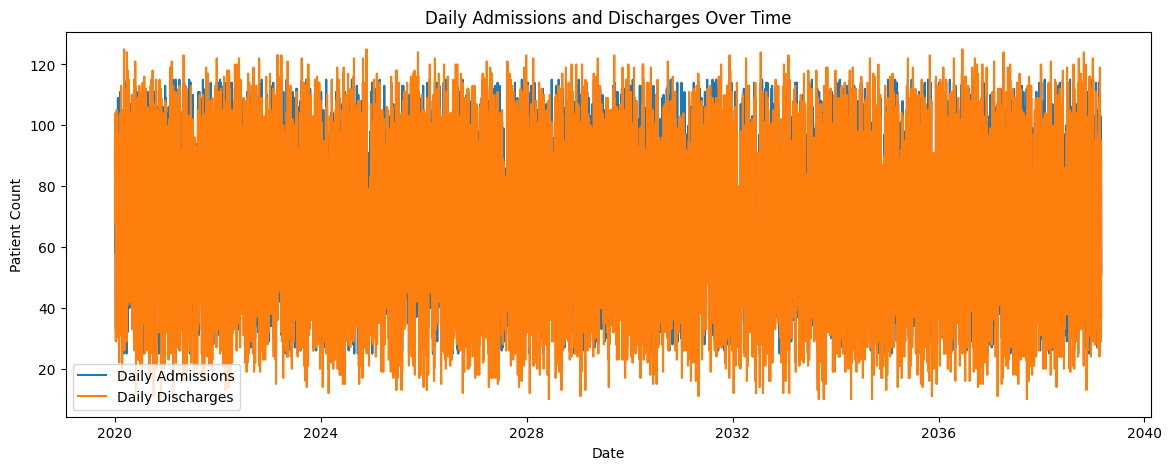

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(
    daily_admission_discharge["Date"],
    daily_admission_discharge["Daily Admissions"],
    label="Daily Admissions"
)
plt.plot(
    daily_admission_discharge["Date"],
    daily_admission_discharge["Daily Discharges"],
    label="Daily Discharges"
)
plt.title("Daily Admissions and Discharges Over Time")
plt.xlabel("Date")
plt.ylabel("Patient Count")
plt.legend()
plt.show()

/tmp/ipykernel_2488/3979122882.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Date", freq="M"))[


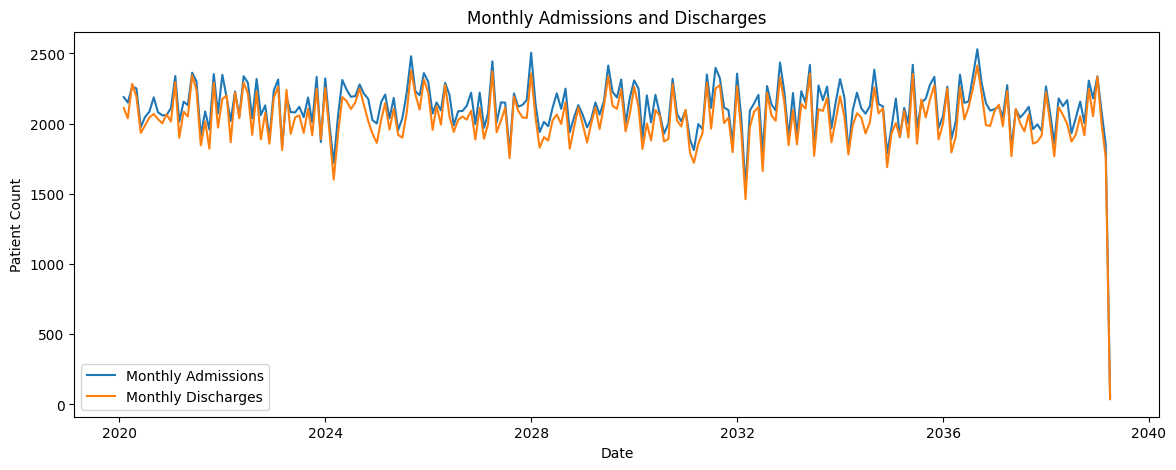

In [ ]:
monthly_admission_discharge = (
    df.groupby(pd.Grouper(key="Date", freq="M"))[
        ["Daily Admissions", "Daily Discharges"]
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_admission_discharge["Date"],
    monthly_admission_discharge["Daily Admissions"],
    label="Monthly Admissions"
)
plt.plot(
    monthly_admission_discharge["Date"],
    monthly_admission_discharge["Daily Discharges"],
    label="Monthly Discharges"
)
plt.title("Monthly Admissions and Discharges")
plt.xlabel("Date")
plt.ylabel("Patient Count")
plt.legend()
plt.show()

In [ ]:
# 16 Identify Seasonal Occupancy Fluctuations

seasonal_occupancy = (
    df.groupby("Season")["Occupancy Rate (%)"]
    .agg(["mean", "min", "max", "std"])
    .sort_values("mean", ascending=False)
)

display(seasonal_occupancy)

,mean,min,max,std
Season,,,,
Autumn,80.052701,64.48,95.0,8.861978
Winter,80.019262,64.65,95.0,8.799558
Summer,79.999828,64.62,95.0,8.948450
Spring,79.544254,64.58,95.0,8.994486


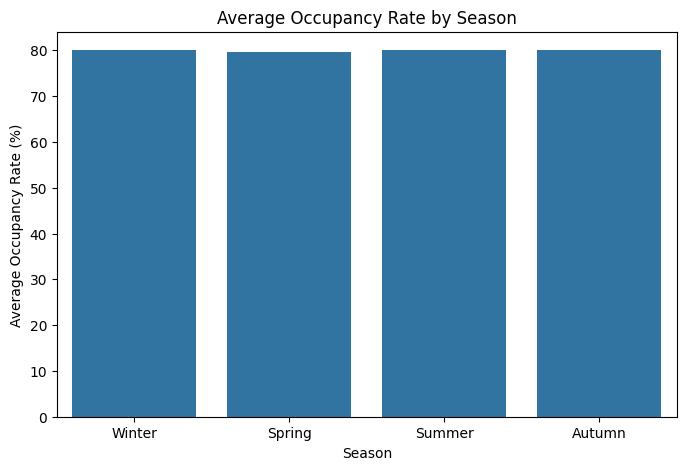

In [ ]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Occupancy Rate (%)",
    order=season_order,
    estimator="mean",
    errorbar=None
)
plt.title("Average Occupancy Rate by Season")
plt.xlabel("Season")
plt.ylabel("Average Occupancy Rate (%)")
plt.show()

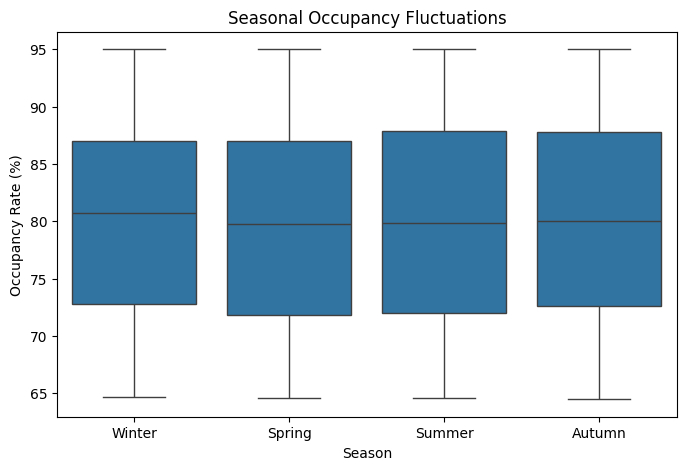

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Season",
    y="Occupancy Rate (%)",
    order=season_order
)
plt.title("Seasonal Occupancy Fluctuations")
plt.xlabel("Season")
plt.ylabel("Occupancy Rate (%)")
plt.show()

In [ ]:
# 17 Analyze Occupancy During Public Holidays

holiday_occupancy = df.groupby("Public Holiday Indicator")[
    ["Occupancy Rate (%)", "Daily Admissions", "Emergency Admissions", "Staff Availability"]
].mean()

display(holiday_occupancy)

,Occupancy Rate (%),Daily Admissions,Emergency Admissions,Staff Availability
Public Holiday Indicator,,,,
No,79.864806,69.897731,27.725142,89.356076
Yes,80.772914,67.976821,26.447020,72.486755


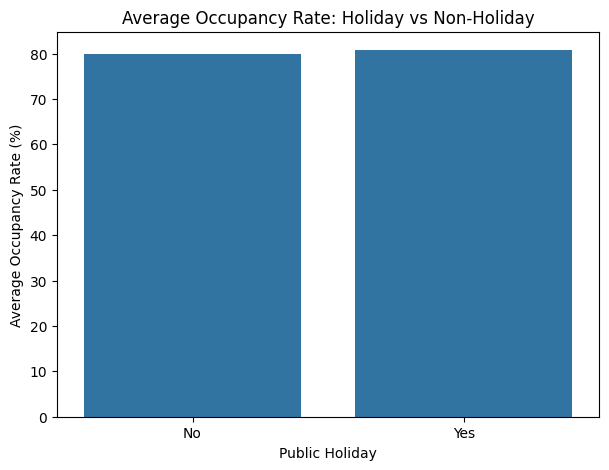

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x="Public Holiday Indicator",
    y="Occupancy Rate (%)",
    estimator="mean",
    errorbar=None
)
plt.title("Average Occupancy Rate: Holiday vs Non-Holiday")
plt.xlabel("Public Holiday")
plt.ylabel("Average Occupancy Rate (%)")
plt.show()

In [ ]:
# 18 Analyze Occupancy During Special Events

event_occupancy = df.groupby("Special Event Indicator")[
    ["Occupancy Rate (%)", "Daily Admissions", "Emergency Admissions", "Staff Availability"]
].mean()

display(event_occupancy)

,Occupancy Rate (%),Daily Admissions,Emergency Admissions,Staff Availability
Special Event Indicator,,,,
No,79.931419,69.648459,27.610177,89.302054
Yes,79.596847,71.677700,28.339721,81.085366


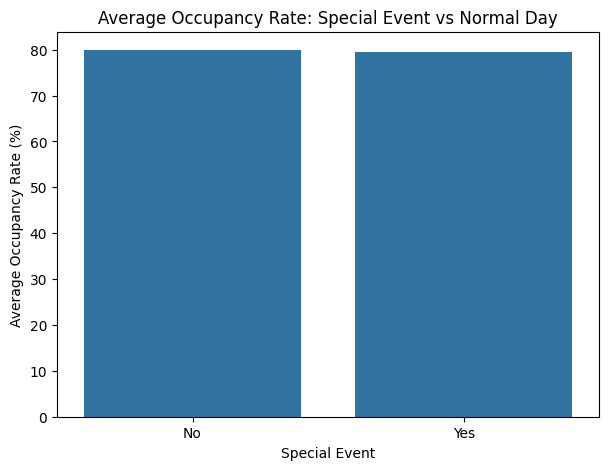

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x="Special Event Indicator",
    y="Occupancy Rate (%)",
    estimator="mean",
    errorbar=None
)
plt.title("Average Occupancy Rate: Special Event vs Normal Day")
plt.xlabel("Special Event")
plt.ylabel("Average Occupancy Rate (%)")
plt.show()

In [ ]:
 # 19 Combined Holiday And Event Impact

holiday_event_impact = df.groupby(
    ["Public Holiday Indicator", "Special Event Indicator"]
)[
    ["Occupancy Rate (%)", "Daily Admissions", "Emergency Admissions", "Staff Availability"]
].mean()

display(holiday_event_impact)

Occupancy Rate (%)  \
Public Holiday Indicator Special Event Indicator                       
No                       No                                79.893186   
                         Yes                               79.547564   
Yes                      No                                80.776942   
                         Yes                               80.726250   

                                                  Daily Admissions  \
Public Holiday Indicator Special Event Indicator                     
No                       No                              69.725277   
                         Yes                             71.825455   
Yes                      No                              67.949640   
                         Yes                             68.291667   

                                                  Emergency Admissions  \
Public Holiday Indicator Special Event Indicator                         
No                       No                                  27.661841   
                         Yes                                 28.432727   
Yes                      No                                  26.467626   
                         Yes                                 26.208333   

                                                  Staff Availability  
Public Holiday Indicator Special Event Indicator                      
No                       No                                90.052049  
                         Yes                               81.576364  
Yes                      No                                72.715827  
                         Yes                               69.833333

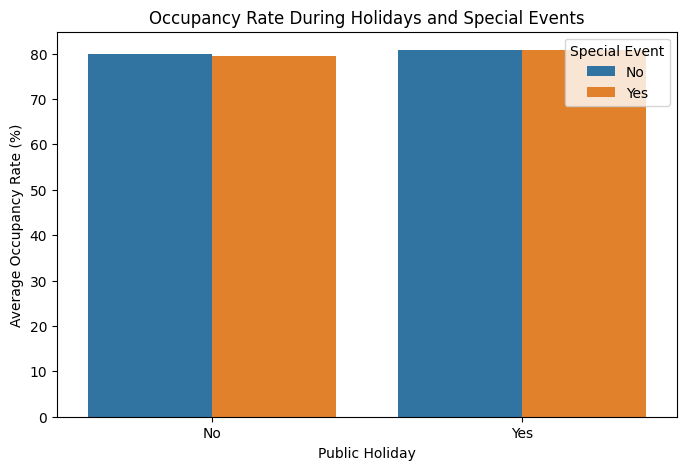

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Public Holiday Indicator",
    y="Occupancy Rate (%)",
    hue="Special Event Indicator",
    estimator="mean",
    errorbar=None
)
plt.title("Occupancy Rate During Holidays and Special Events")
plt.xlabel("Public Holiday")
plt.ylabel("Average Occupancy Rate (%)")
plt.legend(title="Special Event")
plt.show()

In [ ]:
# 20 Generate Trend Reports
monthly_trend_report = df.groupby(pd.Grouper(key="Date", freq="M")).agg({
    "Occupancy Rate (%)": "mean",
    "Daily Admissions": "sum",
    "Daily Discharges": "sum",
    "Emergency Admissions": "sum",
    "ICU Admissions": "sum",
    "Staff Availability": "mean",
    "net_bed_change": "sum"
}).reset_index()

display(monthly_trend_report.head())

/tmp/ipykernel_2488/500224643.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend_report = df.groupby(pd.Grouper(key="Date", freq="M")).agg({


,Date,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Staff Availability,net_bed_change
0,2020-01-31,80.862581,2189,2112,852,228,87.645161,77
1,2020-02-29,80.470690,2150,2038,880,212,89.793103,112
2,2020-03-31,77.286129,2265,2283,918,262,88.806452,-18
3,2020-04-30,79.325333,2251,2192,862,275,90.300000,59
4,2020-05-31,80.660323,1975,1934,752,185,91.129032,41


In [ ]:
yearly_trend_report = df.groupby("Year").agg({
    "Occupancy Rate (%)": "mean",
    "Daily Admissions": "sum",
    "Daily Discharges": "sum",
    "Emergency Admissions": "sum",
    "ICU Admissions": "sum",
    "Staff Availability": "mean",
    "net_bed_change": "sum"
}).reset_index()

display(yearly_trend_report)

,Year,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Staff Availability,net_bed_change
0,2020,79.854208,25460,24773,10042,2815,88.950820,687
1,2021,79.551151,26040,25034,10407,2888,88.668493,1006
2,2022,79.839123,25785,24990,10319,2700,88.706849,795
3,2023,80.053836,25384,24694,10011,2754,88.432877,690
4,2024,79.727760,25395,24254,10015,2761,88.871585,1141
5,2025,80.148849,26363,25357,10104,2862,88.701370,1006
6,2026,80.172932,25539,24538,9816,2713,88.068493,1001
7,2027,79.372356,25735,24813,9980,2801,88.394521,922
8,2028,80.177568,24935,23804,9797,2746,88.896175,1131
9,2029,79.655068,26009,25157,10600,2702,88.873973,852


In [ ]:
department_trend_report = df.groupby("Department").agg({
    "Occupancy Rate (%)": ["mean", "min", "max", "std"],
    "Daily Admissions": "mean",
    "Daily Discharges": "mean",
    "Emergency Admissions": "mean",
    "ICU Admissions": "mean",
    "Staff Availability": "mean",
    "Average Length of Stay": "mean"
})

display(department_trend_report)

Occupancy Rate (%)                         Daily Admissions  \
                               mean    min    max       std             mean   
Department                                                                     
Cardiology                79.967361  64.71  94.99  8.850643        69.759465   
Emergency                 79.875909  64.71  95.00  8.722439        69.533800   
General Medicine          79.929567  64.59  95.00  8.998563        69.081967   
ICU                       79.917551  64.52  95.00  8.874182        70.601665   
Maternity                 80.731972  64.65  94.99  9.044842        70.211009   
Orthopedics               79.337928  64.48  95.00  8.886829        70.589912   
Pediatrics                79.648041  64.68  94.98  8.933200        69.236175   
Surgery                   79.848595  64.66  95.00  8.874756        69.486065   

                 Daily Discharges Emergency Admissions ICU Admissions  \
                             mean                 mean           mean   
Department                                                              
Cardiology              67.136971            27.834076       7.585746   
Emergency               67.400932            27.108392       7.378788   
General Medicine        66.439110            27.585480       7.488290   
ICU                     68.055886            28.184304       7.655172   
Maternity               67.598624            27.807339       7.503440   
Orthopedics             67.667763            27.888158       7.655702   
Pediatrics              66.809908            27.550691       7.354839   
Surgery                 66.618729            27.401338       7.513935   

                 Staff Availability Average Length of Stay  
                               mean                   mean  
Department                                                  
Cardiology                88.394209               4.695100  
Emergency                 88.710956               1.519930  
General Medicine          88.653396               4.696487  
ICU                       88.343639               9.846611  
Maternity                 88.697248               3.031651  
Orthopedics               88.821272               4.766228  
Pediatrics                88.610599               4.773387  
Surgery                   88.780379               6.213155

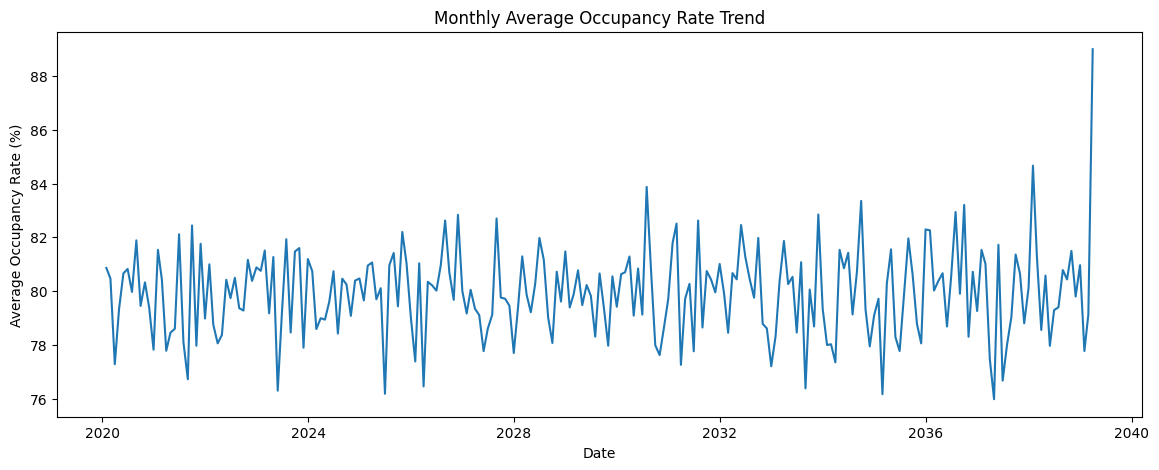

In [ ]:
# 21 Visualize Trend Report

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend_report["Date"], monthly_trend_report["Occupancy Rate (%)"])
plt.title("Monthly Average Occupancy Rate Trend")
plt.xlabel("Date")
plt.ylabel("Average Occupancy Rate (%)")
plt.show()

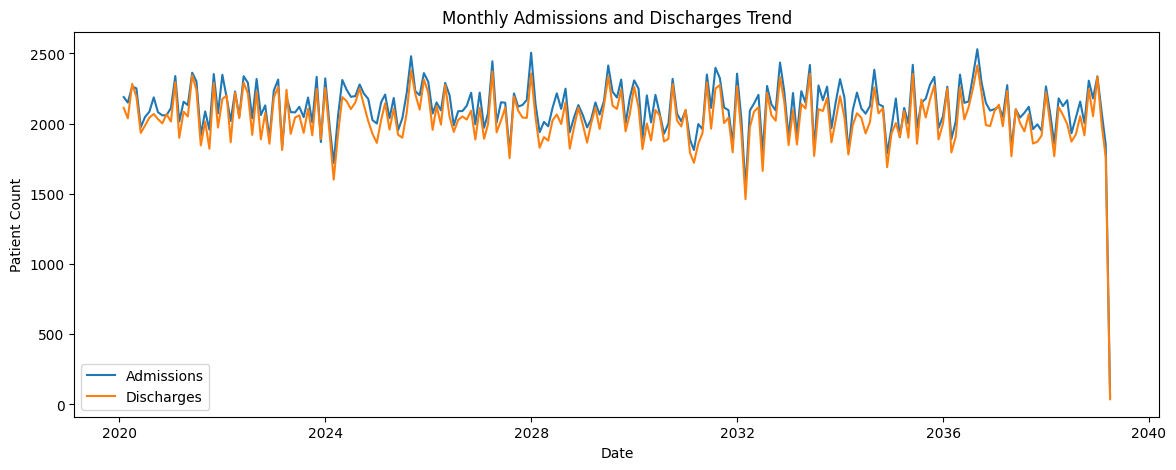

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_trend_report["Date"], monthly_trend_report["Daily Admissions"], label="Admissions")
plt.plot(monthly_trend_report["Date"], monthly_trend_report["Daily Discharges"], label="Discharges")
plt.title("Monthly Admissions and Discharges Trend")
plt.xlabel("Date")
plt.ylabel("Patient Count")
plt.legend()
plt.show()

In [ ]:
#22  Generate Correlation Report

numeric_columns = [
    "Total Hospital Beds",
    "Beds Occupied",
    "Occupancy Rate (%)",
    "Daily Admissions",
    "Daily Discharges",
    "Emergency Admissions",
    "ICU Admissions",
    "Staff Availability",
    "Average Length of Stay",
    "net_bed_change"
]

correlation_report = df[numeric_columns].corr()

display(correlation_report)

,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Staff Availability,Average Length of Stay,net_bed_change
Total Hospital Beds,1.000000,0.905666,-0.006065,-0.010903,-0.010852,0.003803,-0.000610,0.015406,-0.016589,0.001149
Beds Occupied,0.905666,1.000000,0.406245,-0.015910,-0.015959,-0.001098,-0.010697,0.012825,-0.019462,0.002123
Occupancy Rate (%),-0.006065,0.406245,1.000000,-0.010443,-0.009907,-0.008413,-0.021374,-0.003366,-0.004199,-0.000656
Daily Admissions,-0.010903,-0.015910,-0.010443,1.000000,0.960989,0.847505,0.698717,0.006992,0.011789,0.018528
Daily Discharges,-0.010852,-0.015959,-0.009907,0.960989,1.000000,0.817056,0.673082,0.003803,0.007374,-0.258733
Emergency Admissions,0.003803,-0.001098,-0.008413,0.847505,0.817056,1.000000,0.602527,0.011888,0.019253,0.006260
ICU Admissions,-0.000610,-0.010697,-0.021374,0.698717,0.673082,0.602527,1.000000,0.009257,0.014979,0.007080
Staff Availability,0.015406,0.012825,-0.003366,0.006992,0.003803,0.011888,0.009257,1.000000,-0.022205,0.010669
Average Length of Stay,-0.016589,-0.019462,-0.004199,0.011789,0.007374,0.019253,0.014979,-0.022205,1.000000,0.014513
net_bed_change,0.001149,0.002123,-0.000656,0.018528,-0.258733,0.006260,0.007080,0.010669,0.014513,1.000000


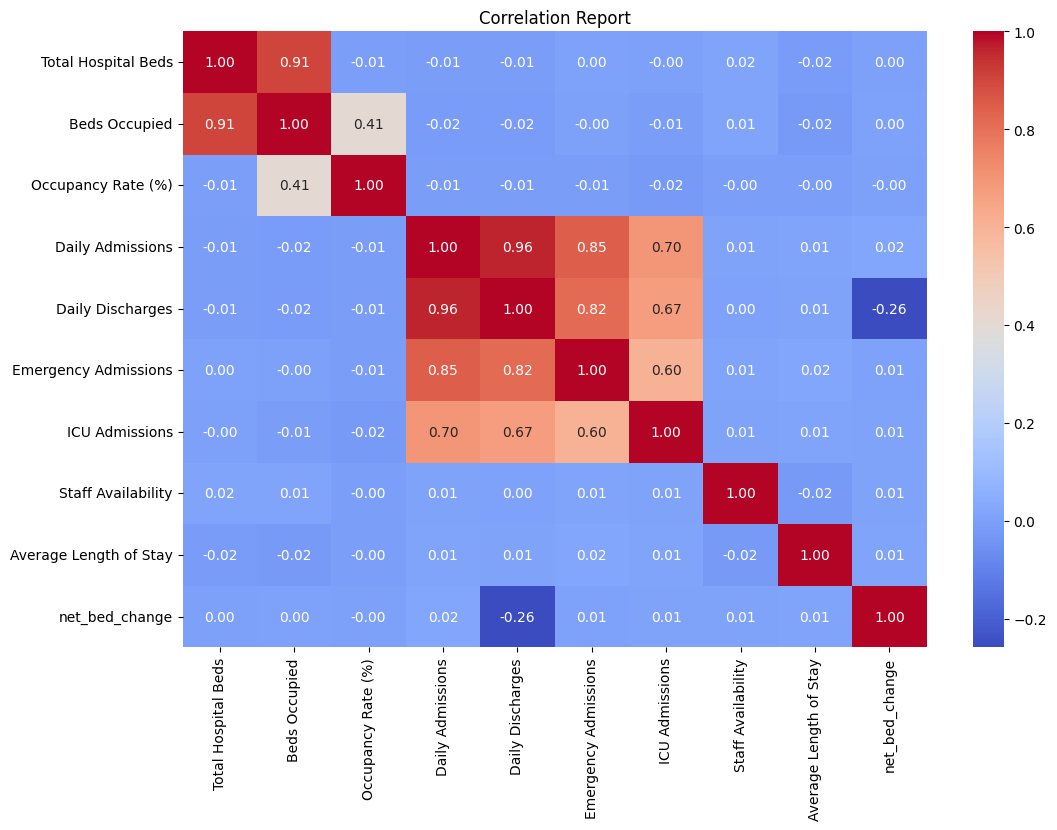

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_report,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Report")
plt.show()

In [ ]:
 #23 Engineer Forecasting-Related Features

df["Month Number"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day of Year"] = df["Date"].dt.dayofyear
df["Week of Year"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["Is Weekend"] = df["Date"].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
df["Holiday Flag"] = df["Public Holiday Indicator"].map({
    "Yes": 1,
    "No": 0
})

df["Special Event Flag"] = df["Special Event Indicator"].map({
    "Yes": 1,
    "No": 0
})

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

if "Day of Week" not in df.columns:
    df["Day of Week"] = df["Date"].dt.day_name()

df["Department Encoded"] = df["Department"].astype("category").cat.codes
df["Season Encoded"] = df["Season"].astype("category").cat.codes
df["Day of Week Encoded"] = df["Day of Week"].astype("category").cat.codes

In [ ]:
df = df.sort_values(["Department", "Date"]).reset_index(drop=True)

df["Lag Occupancy 1 Day"] = df.groupby("Department")["Occupancy Rate (%)"].shift(1)
df["Lag Occupancy 7 Days"] = df.groupby("Department")["Occupancy Rate (%)"].shift(7)

df["Rolling Occupancy 7 Days"] = (
    df.groupby("Department")["Occupancy Rate (%)"]
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)

df["Rolling Admissions 7 Days"] = (
    df.groupby("Department")["Daily Admissions"]
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)

In [ ]:
df = df.dropna().reset_index(drop=True)

display(df.head())
print(df.shape)

,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,...,Holiday Flag,Special Event Flag,Day of Week,Department Encoded,Season Encoded,Day of Week Encoded,Lag Occupancy 1 Day,Lag Occupancy 7 Days,Rolling Occupancy 7 Days,Rolling Admissions 7 Days
0,2020-02-09,Sunday,February,Winter,442,331,74.89,33,31,18,...,0,0,Sunday,0,3,3,71.62,67.82,78.472857,81.285714
1,2020-02-18,Tuesday,February,Winter,285,267,93.68,98,95,26,...,0,0,Tuesday,0,3,5,74.89,75.78,81.030000,81.428571
2,2020-03-01,Sunday,March,Spring,371,322,86.79,72,71,18,...,0,0,Sunday,0,1,3,93.68,92.79,80.172857,82.428571
3,2020-03-02,Monday,March,Spring,384,334,86.98,83,78,41,...,0,0,Monday,0,1,1,86.79,67.99,82.885714,84.428571
4,2020-03-22,Sunday,March,Spring,440,334,75.91,90,83,45,...,0,0,Sunday,0,1,3,86.98,84.54,81.652857,82.714286


(6944, 35)


In [ ]:
# 23 Prepare Training And Testing Datasets

# Use occupancy rate as the prediction target.

target = "Occupancy Rate (%)"

features = [
    "Total Hospital Beds",
    "Beds Occupied",
    "Daily Admissions",
    "Daily Discharges",
    "Emergency Admissions",
    "ICU Admissions",
    "Staff Availability",
    "Average Length of Stay",
    "net_bed_change",
    "Year",
    "Month Number",
    "Day",
    "Day of Year",
    "Week of Year",
    "Quarter",
    "Is Weekend",
    "Holiday Flag",
    "Special Event Flag",
    "Department Encoded",
    "Season Encoded",
    "Day of Week Encoded",
    "Lag Occupancy 1 Day",
    "Lag Occupancy 7 Days",
    "Rolling Occupancy 7 Days",
    "Rolling Admissions 7 Days"
]

In [ ]:
X = df[features]
y = df[target]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (6944, 25)
Target dataset shape: (6944,)


In [ ]:
# Time-Based Train-Test Split

df = df.sort_values("Date").reset_index(drop=True)

split_index = int(len(df) * 0.8)

train_data = df.iloc[:split_index]
test_data = df.iloc[split_index:]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5555, 25)
y_train: (5555,)
X_test: (1389, 25)
y_test: (1389,)


In [ ]:
train_data.to_csv("hospital_train_dataset.csv", index=False)
test_data.to_csv("hospital_test_dataset.csv", index=False)

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [ ]:
from google.colab import files

files.download("hospital_train_dataset.csv")
files.download("hospital_test_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
avg_occ = df["Occupancy Rate (%)"].mean()
highest_dept = df.groupby("Department")["Occupancy Rate (%)"].mean().idxmax()
lowest_dept = df.groupby("Department")["Occupancy Rate (%)"].mean().idxmin()
highest_season = df.groupby("Season")["Occupancy Rate (%)"].mean().idxmax()

print("Average Occupancy Rate:", round(avg_occ, 2))
print("Highest Occupancy Department:", highest_dept)
print("Lowest Occupancy Department:", lowest_dept)
print("Highest Occupancy Season:", highest_season)

Average Occupancy Rate: 79.9
Highest Occupancy Department: Maternity
Lowest Occupancy Department: Orthopedics
Highest Occupancy Season: Autumn


In [ ]:
#Day 2 Objective
#Add to chat
#The objective of Day 2 is to select suitable forecasting algorithms, train multiple regression models, and compare their performance using forecasting metrics.

#1. Import Model Libraries

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
# 4. Create Evaluation Function

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE (%)": mape
    }

In [ ]:
# 5. Train Multiple Forecasting Models

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
}

In [ ]:
results = []

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    trained_models[model_name] = model

    results.append(
        evaluate_model(model_name, y_test, y_pred)
    )

In [ ]:
# 6. Compare Model Performance

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

display(results_df)

,Model,MAE,RMSE,R2 Score,MAPE (%)
1,Random Forest Regressor,0.355484,0.495219,0.996914,0.448465
3,XGBoost Regressor,0.488345,0.622167,0.995128,0.615814
2,Gradient Boosting Regressor,0.964290,1.260714,0.979997,1.218147
0,Linear Regression,1.606711,2.150100,0.941818,2.052283


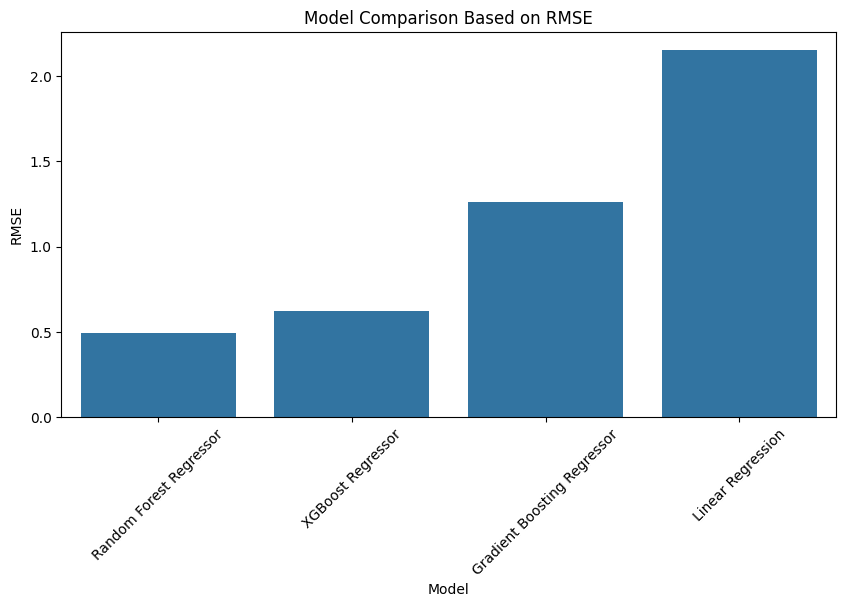

In [ ]:
# 7. Visualize Model Comparison

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xticks(rotation=45)
plt.show()

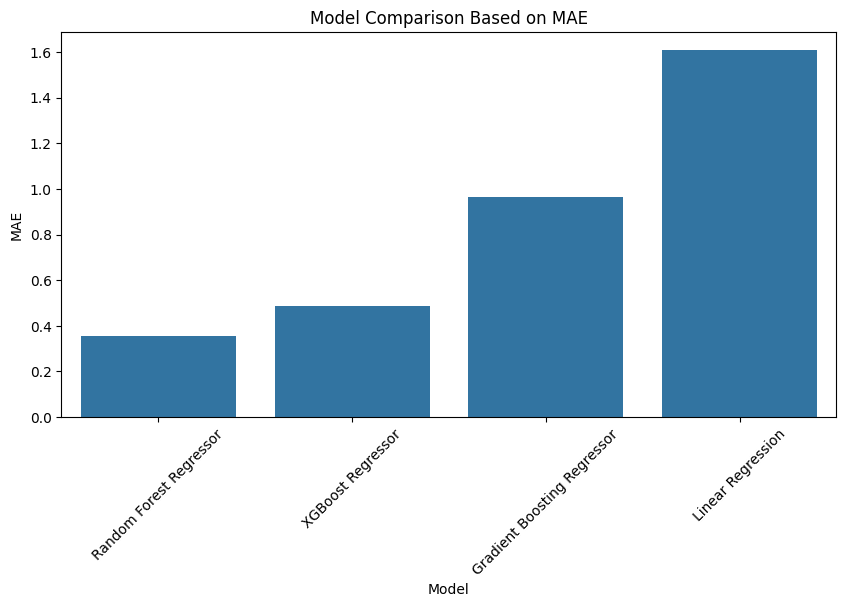

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="MAE")
plt.title("Model Comparison Based on MAE")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 8. Select Best Model

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest Regressor


In [ ]:
# 9. Actual vs Predicted Values

best_predictions = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual Occupancy Rate": y_test.values,
    "Predicted Occupancy Rate": best_predictions
})

display(comparison_df.head(10))

,Actual Occupancy Rate,Predicted Occupancy Rate
0,65.71,67.4068
1,84.98,85.0100
2,68.92,68.7761
3,93.83,93.8474
4,71.76,72.0187
5,73.89,74.2112
6,70.96,70.5877
7,80.73,80.4999
8,92.86,92.0578
9,67.83,67.8653


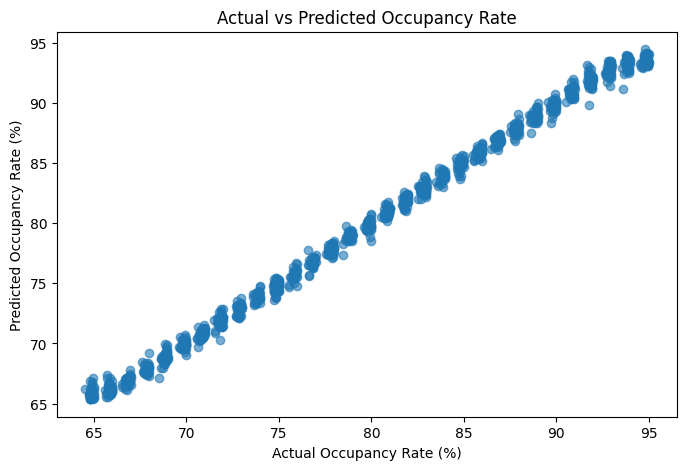

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    comparison_df["Actual Occupancy Rate"],
    comparison_df["Predicted Occupancy Rate"],
    alpha=0.6
)
plt.xlabel("Actual Occupancy Rate (%)")
plt.ylabel("Predicted Occupancy Rate (%)")
plt.title("Actual vs Predicted Occupancy Rate")
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)
mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("XGBoost Regressor Performance")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))
print("MAPE (%):", round(mape, 2))

XGBoost Regressor Performance
MAE: 0.7
RMSE: 0.94
R2 Score: 0.9889
MAPE (%): 0.88


In [ ]:
# 1. Import Required Libraries

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
# If XGBoost is not installed:

!pip install xgboost

In [ ]:
# 2. Evaluation Function

def evaluate_forecasting_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [ ]:
# 3. Train Baseline Models

baseline_models = {
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

baseline_results = []
trained_baseline_models = {}

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    trained_baseline_models[model_name] = model
    baseline_results.append(
        evaluate_forecasting_model(model_name, y_test, y_pred)
    )

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values(by="RMSE")

display(baseline_results_df)

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,0.355484,0.245242,0.495219,0.996914
2,XGBoost Regressor,0.585308,0.565292,0.751859,0.992886
1,Gradient Boosting Regressor,0.964290,1.589400,1.260714,0.979997


In [ ]:
#4. Model Tuning And Optimization

# Use smaller grids so Colab runs faster.

tscv = TimeSeriesSplit(n_splits=3)

# Random Forest Tuning

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# Gradient Boosting Tuning

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_params,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
# XGBoost Tuning

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_params,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# 5. Evaluate Tuned Models

tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_,
    "Tuned XGBoost": xgb_grid.best_estimator_
}

tuned_results = []
trained_tuned_models = {}

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    trained_tuned_models[model_name] = model
    tuned_results.append(
        evaluate_forecasting_model(model_name, y_test, y_pred)
    )

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by="RMSE")

display(tuned_results_df)

,Model,MAE,MSE,RMSE,R2 Score
0,Tuned Random Forest,0.342179,0.232500,0.482182,0.997074
1,Tuned Gradient Boosting,0.426326,0.302186,0.549714,0.996197
2,Tuned XGBoost,0.465052,0.354678,0.595548,0.995536


In [ ]:
# 6. Compare Baseline And Tuned Models

final_results_df = pd.concat(
    [baseline_results_df, tuned_results_df],
    ignore_index=True
)

final_results_df = final_results_df.sort_values(by="RMSE")

display(final_results_df)

,Model,MAE,MSE,RMSE,R2 Score
3,Tuned Random Forest,0.342179,0.232500,0.482182,0.997074
0,Random Forest Regressor,0.355484,0.245242,0.495219,0.996914
4,Tuned Gradient Boosting,0.426326,0.302186,0.549714,0.996197
5,Tuned XGBoost,0.465052,0.354678,0.595548,0.995536
1,XGBoost Regressor,0.585308,0.565292,0.751859,0.992886
2,Gradient Boosting Regressor,0.964290,1.589400,1.260714,0.979997


In [ ]:
# 7. Select Best-Performing Forecasting Model

best_model_name = final_results_df.iloc[0]["Model"]

all_models = {}
all_models.update(trained_baseline_models)
all_models.update(trained_tuned_models)

best_model = all_models[best_model_name]

print("Best Performing Forecasting Model:", best_model_name)

Best Performing Forecasting Model: Tuned Random Forest


In [ ]:
best_predictions = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, best_predictions)
best_mse = mean_squared_error(y_test, best_predictions)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_predictions)

print("Best Model Performance")
print("MAE:", round(best_mae, 2))
print("MSE:", round(best_mse, 2))
print("RMSE:", round(best_rmse, 2))
print("R2 Score:", round(best_r2, 4))

Best Model Performance
MAE: 0.34
MSE: 0.23
RMSE: 0.48
R2 Score: 0.9971


In [ ]:
best_model

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
# Prepare Latest 7 Records As Forecast Base

# This method uses the latest available test records to produce a simple 7-day forecast.

forecast_features = features.copy()

latest_data = df.sort_values("Date").tail(7).copy()

future_X = latest_data[forecast_features]

future_predictions = best_model.predict(future_X)

In [ ]:
 # Create 7-Day Future Date Range

last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

In [ ]:
 # Create 7-Day Forecast Table

forecast_df = pd.DataFrame({
    "Forecast Date": future_dates,
    "Predicted Occupancy Rate (%)": future_predictions
})

forecast_df["Predicted Occupancy Rate (%)"] = forecast_df["Predicted Occupancy Rate (%)"].round(2)

display(forecast_df)

,Forecast Date,Predicted Occupancy Rate (%)
0,2039-03-02,70.76
1,2039-03-03,76.94
2,2039-03-04,72.83
3,2039-03-05,67.50
4,2039-03-06,88.46
5,2039-03-07,78.33
6,2039-03-08,88.40


In [ ]:
 # Add Capacity Utilization Category

def capacity_status(occupancy):
    if occupancy < 70:
        return "Low Utilization"
    elif occupancy < 85:
        return "Moderate Utilization"
    elif occupancy < 95:
        return "High Utilization"
    else:
        return "Critical Utilization"

forecast_df["Capacity Status"] = forecast_df["Predicted Occupancy Rate (%)"].apply(capacity_status)

display(forecast_df)

,Forecast Date,Predicted Occupancy Rate (%),Capacity Status
0,2039-03-02,70.76,Moderate Utilization
1,2039-03-03,76.94,Moderate Utilization
2,2039-03-04,72.83,Moderate Utilization
3,2039-03-05,67.50,Low Utilization
4,2039-03-06,88.46,High Utilization
5,2039-03-07,78.33,Moderate Utilization
6,2039-03-08,88.40,High Utilization


In [ ]:
 # Analyze Future Capacity Utilization Trends

avg_forecast_occupancy = forecast_df["Predicted Occupancy Rate (%)"].mean()
max_forecast_occupancy = forecast_df["Predicted Occupancy Rate (%)"].max()
min_forecast_occupancy = forecast_df["Predicted Occupancy Rate (%)"].min()

highest_day = forecast_df.loc[
    forecast_df["Predicted Occupancy Rate (%)"].idxmax(),
    "Forecast Date"
]

print("Average 7-Day Forecast Occupancy:", round(avg_forecast_occupancy, 2))
print("Maximum Forecast Occupancy:", round(max_forecast_occupancy, 2))
print("Minimum Forecast Occupancy:", round(min_forecast_occupancy, 2))
print("Highest Occupancy Forecast Date:", highest_day)


Average 7-Day Forecast Occupancy: 77.6
Maximum Forecast Occupancy: 88.46
Minimum Forecast Occupancy: 67.5
Highest Occupancy Forecast Date: 2039-03-06 00:00:00


In [ ]:
forecast_df["Capacity Status"].value_counts()

,count
Capacity Status,
Moderate Utilization,4
High Utilization,2
Low Utilization,1


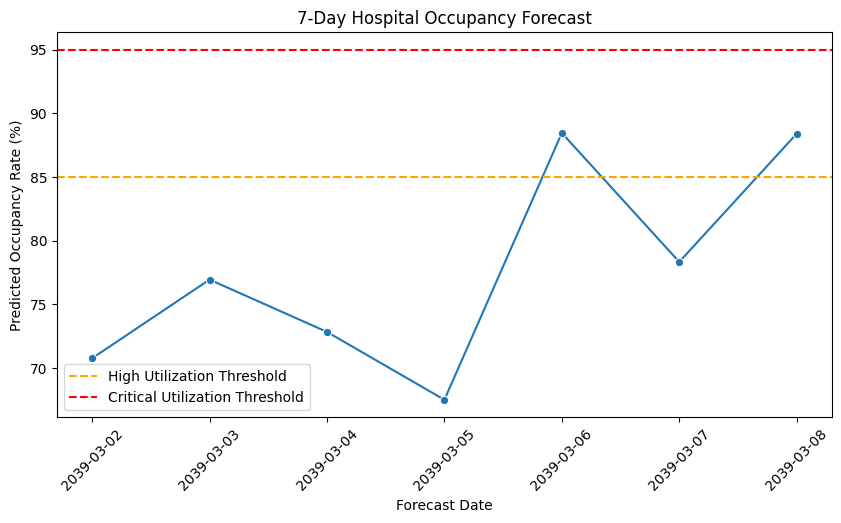

In [ ]:
# Visualize 7-Day Occupancy Forecast

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=forecast_df,
    x="Forecast Date",
    y="Predicted Occupancy Rate (%)",
    marker="o"
)
plt.axhline(85, color="orange", linestyle="--", label="High Utilization Threshold")
plt.axhline(95, color="red", linestyle="--", label="Critical Utilization Threshold")
plt.title("7-Day Hospital Occupancy Forecast")
plt.xlabel("Forecast Date")
plt.ylabel("Predicted Occupancy Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
 # Create Dashboard-Style Summary

dashboard_summary = {
    "Average Forecast Occupancy (%)": round(avg_forecast_occupancy, 2),
    "Highest Forecast Occupancy (%)": round(max_forecast_occupancy, 2),
    "Lowest Forecast Occupancy (%)": round(min_forecast_occupancy, 2),
    "Highest Occupancy Date": highest_day,
    "Most Common Capacity Status": forecast_df["Capacity Status"].mode()[0]
}

dashboard_summary_df = pd.DataFrame(
    dashboard_summary.items(),
    columns=["Metric", "Value"]
)

display(dashboard_summary_df)

,Metric,Value
0,Average Forecast Occupancy (%),77.6
1,Highest Forecast Occupancy (%),88.46
2,Lowest Forecast Occupancy (%),67.5
3,Highest Occupancy Date,2039-03-06 00:00:00
4,Most Common Capacity Status,Moderate Utilization


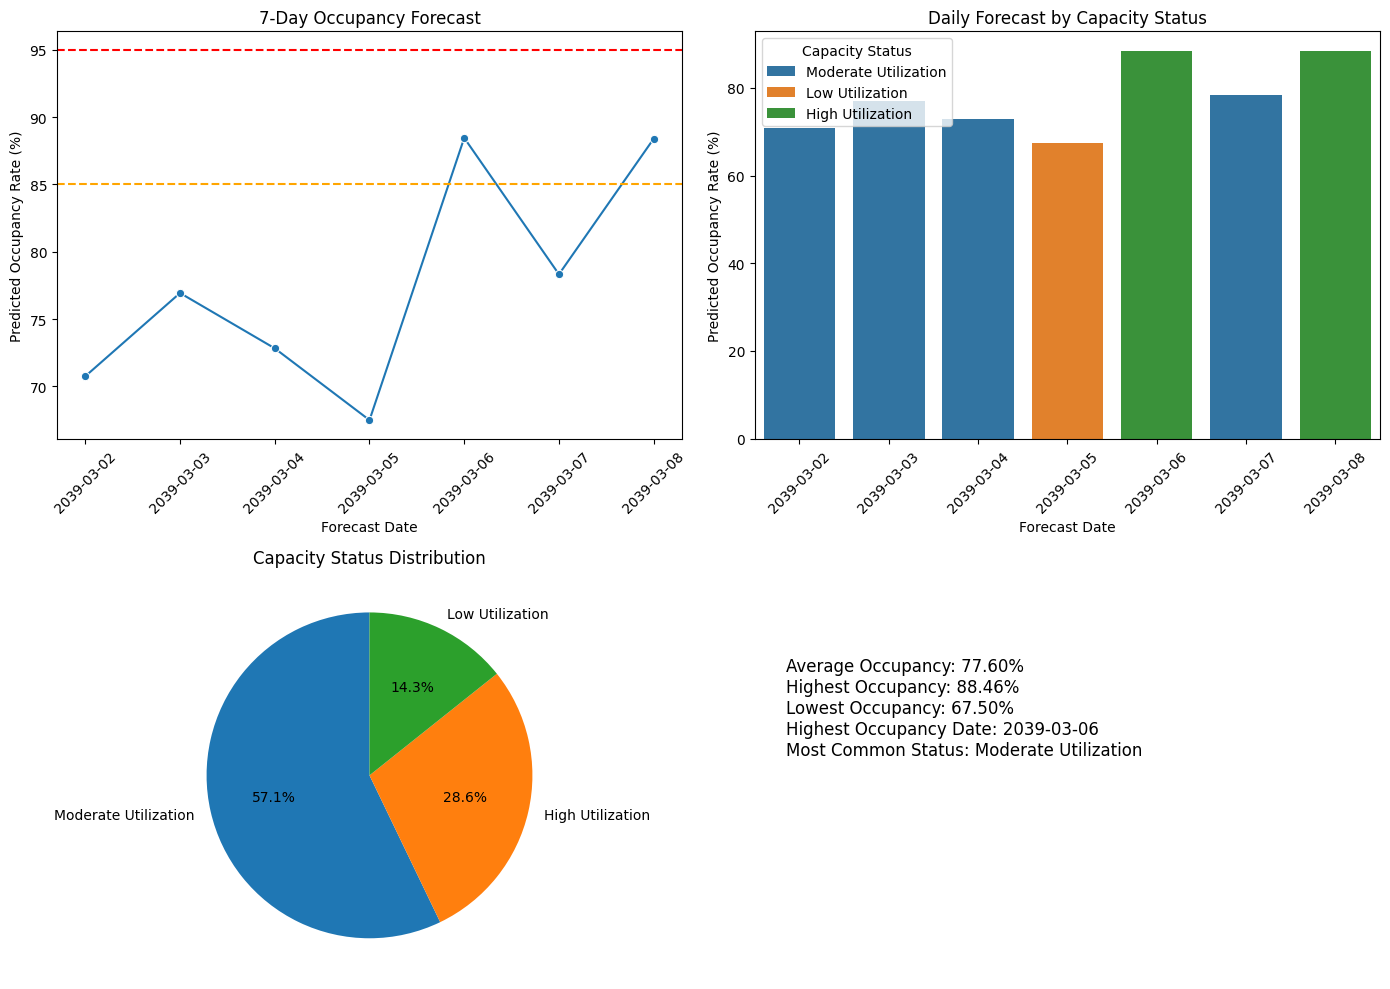

In [ ]:
 # Forecasting Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(
    data=forecast_df,
    x="Forecast Date",
    y="Predicted Occupancy Rate (%)",
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].axhline(85, color="orange", linestyle="--")
axes[0, 0].axhline(95, color="red", linestyle="--")
axes[0, 0].set_title("7-Day Occupancy Forecast")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=forecast_df,
    x="Forecast Date",
    y="Predicted Occupancy Rate (%)",
    hue="Capacity Status",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Daily Forecast by Capacity Status")
axes[0, 1].tick_params(axis="x", rotation=45)

status_counts = forecast_df["Capacity Status"].value_counts()
axes[1, 0].pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1, 0].set_title("Capacity Status Distribution")

axes[1, 1].axis("off")
summary_text = f"""
Average Occupancy: {avg_forecast_occupancy:.2f}%
Highest Occupancy: {max_forecast_occupancy:.2f}%
Lowest Occupancy: {min_forecast_occupancy:.2f}%
Highest Occupancy Date: {highest_day.date()}
Most Common Status: {forecast_df["Capacity Status"].mode()[0]}
"""
axes[1, 1].text(0.05, 0.5, summary_text, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Save Forecast Results

forecast_df.to_csv("seven_day_occupancy_forecast.csv", index=False)

from google.colab import files
files.download("seven_day_occupancy_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
forecast_df[
    [
        "Forecast Date",
        "Predicted Occupancy Rate (%)",
        "Capacity Status"
    ]
].head()

,Forecast Date,Predicted Occupancy Rate (%),Capacity Status
0,2039-03-02,70.76,Moderate Utilization
1,2039-03-03,76.94,Moderate Utilization
2,2039-03-04,72.83,Moderate Utilization
3,2039-03-05,67.50,Low Utilization
4,2039-03-06,88.46,High Utilization


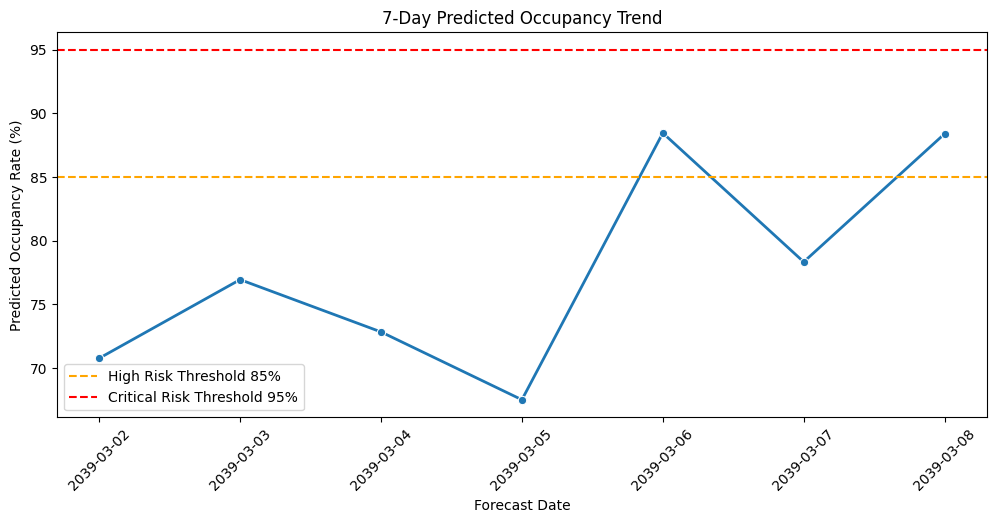

NameError: name 'risk_colors' is not defined

<Figure size 1200x500 with 0 Axes>

In [ ]:
 # Occupancy Trend Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=forecast_df,
    x="Forecast Date",
    y="Predicted Occupancy Rate (%)",
    marker="o",
    linewidth=2
)

plt.axhline(85, color="orange", linestyle="--", label="High Risk Threshold 85%")
plt.axhline(95, color="red", linestyle="--", label="Critical Risk Threshold 95%")

plt.title("7-Day Predicted Occupancy Trend")
plt.xlabel("Forecast Date")
plt.ylabel("Predicted Occupancy Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=forecast_df,
    x="Forecast Date",
    y="Predicted Occupancy Rate (%)",
    hue="Overflow Risk Level",
    palette=risk_colors
)

plt.axhline(85, color="orange", linestyle="--")
plt.axhline(95, color="red", linestyle="--")

plt.title("Predicted Occupancy with Overflow Risk Levels")
plt.xlabel("Forecast Date")
plt.ylabel("Predicted Occupancy Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Risk Level")
plt.show()

In [ ]:
# Color-Coded Occupancy Bar Chart

def risk_level(occupancy):
    if occupancy < 70:
        return "Low"
    elif occupancy < 85:
        return "Moderate"
    elif occupancy < 95:
        return "High"
    else:
        return "Critical"

forecast_df["Overflow Risk Level"] = forecast_df["Predicted Occupancy Rate (%)"].apply(risk_level)

risk_colors = {
    "Low": "green",
    "Moderate": "skyblue",
    "High": "orange",
    "Critical": "red"
}


In [ ]:
 # Overflow Risk Detection Logic

def overflow_alert(occupancy):
    if occupancy >= 95:
        return "CRITICAL ALERT: Predicted occupancy above 95%. Immediate capacity action required."
    elif occupancy >= 85:
        return "HIGH ALERT: Predicted occupancy above 85%. Prepare additional beds and staff."
    elif occupancy >= 70:
        return "MODERATE: Occupancy is stable but should be monitored."
    else:
        return "LOW: Occupancy is within safe capacity range."

forecast_df["Overflow Alert"] = forecast_df["Predicted Occupancy Rate (%)"].apply(overflow_alert)

display(forecast_df)

,Forecast Date,Predicted Occupancy Rate (%),Capacity Status,Overflow Risk Level,Overflow Alert
0,2039-03-02,70.76,Moderate Utilization,Moderate,MODERATE: Occupancy is stable but should be mo...
1,2039-03-03,76.94,Moderate Utilization,Moderate,MODERATE: Occupancy is stable but should be mo...
2,2039-03-04,72.83,Moderate Utilization,Moderate,MODERATE: Occupancy is stable but should be mo...
3,2039-03-05,67.50,Low Utilization,Low,LOW: Occupancy is within safe capacity range.
4,2039-03-06,88.46,High Utilization,High,HIGH ALERT: Predicted occupancy above 85%. Pre...
5,2039-03-07,78.33,Moderate Utilization,Moderate,MODERATE: Occupancy is stable but should be mo...
6,2039-03-08,88.40,High Utilization,High,HIGH ALERT: Predicted occupancy above 85%. Pre...


In [ ]:
# Generate Alerts For Predicted Occupancy Above Threshold

high_risk_alerts = forecast_df[
    forecast_df["Predicted Occupancy Rate (%)"] >= 85
]

display(high_risk_alerts[
    ["Forecast Date", "Predicted Occupancy Rate (%)", "Overflow Risk Level", "Overflow Alert"]
])

,Forecast Date,Predicted Occupancy Rate (%),Overflow Risk Level,Overflow Alert
4,2039-03-06,88.46,High,HIGH ALERT: Predicted occupancy above 85%. Pre...
6,2039-03-08,88.40,High,HIGH ALERT: Predicted occupancy above 85%. Pre...


In [ ]:
if len(high_risk_alerts) > 0:
    print("Overflow Risk Alerts Generated:")
    for index, row in high_risk_alerts.iterrows():
        print(
            row["Forecast Date"].strftime("%Y-%m-%d"),
            "-",
            row["Overflow Risk Level"],
            "-",
            round(row["Predicted Occupancy Rate (%)"], 2),
            "%",
            "-",
            row["Overflow Alert"]
        )
else:
    print("No overflow risk alerts. Predicted occupancy is below high-risk threshold.")

Overflow Risk Alerts Generated:
2039-03-06 - High - 88.46 % - HIGH ALERT: Predicted occupancy above 85%. Prepare additional beds and staff.
2039-03-08 - High - 88.4 % - HIGH ALERT: Predicted occupancy above 85%. Prepare additional beds and staff.


In [ ]:
# Alert Summary

alert_summary = forecast_df["Overflow Risk Level"].value_counts().reset_index()
alert_summary.columns = ["Overflow Risk Level", "Number of Days"]

display(alert_summary)

,Overflow Risk Level,Number of Days
0,Moderate,4
1,High,2
2,Low,1


/tmp/ipykernel_2488/4231423914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


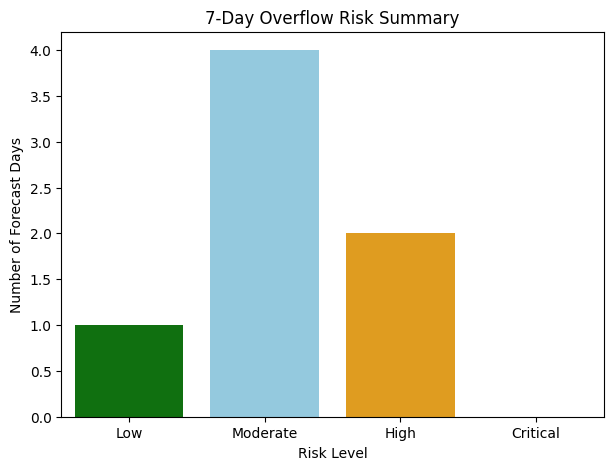

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=alert_summary,
    x="Overflow Risk Level",
    y="Number of Days",
    order=["Low", "Moderate", "High", "Critical"],
    palette=risk_colors
)

plt.title("7-Day Overflow Risk Summary")
plt.xlabel("Risk Level")
plt.ylabel("Number of Forecast Days")
plt.show()

In [ ]:
 # Save Forecast Alert Report

forecast_df.to_csv("occupancy_forecast_alert_report.csv", index=False)

from google.colab import files
files.download("occupancy_forecast_alert_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create Capacity Planning Recommendations

def capacity_recommendation(row):
    occupancy = row["Predicted Occupancy Rate (%)"]
    risk = row["Overflow Risk Level"]

    if risk == "Critical":
        return (
            "Activate emergency capacity plan, open overflow beds, increase ICU and emergency staff, "
            "postpone non-urgent admissions if needed, and review discharge readiness."
        )
    elif risk == "High":
        return (
            "Prepare additional beds, increase staff coverage, monitor emergency admissions closely, "
            "and speed up discharge planning."
        )
    elif risk == "Moderate":
        return (
            "Maintain regular operations, monitor admissions and discharges, and keep backup staffing ready."
        )
    else:
        return (
            "Capacity is stable. Continue routine monitoring and normal staffing levels."
        )

forecast_df["Capacity Planning Recommendation"] = forecast_df.apply(capacity_recommendation, axis=1)

display(forecast_df[
    [
        "Forecast Date",
        "Predicted Occupancy Rate (%)",
        "Overflow Risk Level",
        "Overflow Alert",
        "Capacity Planning Recommendation"
    ]
])

,Forecast Date,Predicted Occupancy Rate (%),Overflow Risk Level,Overflow Alert,Capacity Planning Recommendation
0,2039-03-02,70.76,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
1,2039-03-03,76.94,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
2,2039-03-04,72.83,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
3,2039-03-05,67.50,Low,LOW: Occupancy is within safe capacity range.,Capacity is stable. Continue routine monitorin...
4,2039-03-06,88.46,High,HIGH ALERT: Predicted occupancy above 85%. Pre...,"Prepare additional beds, increase staff covera..."
5,2039-03-07,78.33,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
6,2039-03-08,88.40,High,HIGH ALERT: Predicted occupancy above 85%. Pre...,"Prepare additional beds, increase staff covera..."


In [ ]:
# Create Recommendation Summary

recommendation_summary = forecast_df.groupby("Overflow Risk Level").agg({
    "Forecast Date": "count",
    "Predicted Occupancy Rate (%)": "mean"
}).reset_index()

recommendation_summary.columns = [
    "Overflow Risk Level",
    "Number of Forecast Days",
    "Average Predicted Occupancy (%)"
]

display(recommendation_summary)


,Overflow Risk Level,Number of Forecast Days,Average Predicted Occupancy (%)
0,High,2,88.430
1,Low,1,67.500
2,Moderate,4,74.715


In [ ]:
# Save Capacity Planning Report

forecast_df.to_csv("capacity_planning_recommendations.csv", index=False)
from google.colab import files

files.download("capacity_planning_recommendations.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Export And Save The Trained Model

# Use joblib to save your trained Random Forest model.

import joblib

joblib.dump(best_model, "best_occupancy_forecasting_model.pkl")
#Download the model file:

files.download("best_occupancy_forecasting_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save Feature List Also

# This is important. When you load the model later, you need the same feature order.

joblib.dump(features, "model_features.pkl")

files.download("model_features.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Test Loading The Saved Model

loaded_model = joblib.load("best_occupancy_forecasting_model.pkl")
loaded_features = joblib.load("model_features.pkl")

test_prediction = loaded_model.predict(X_test[loaded_features].head(5))

print(test_prediction)

[67.286   84.9559  68.68985 93.6306  71.9356 ]


In [ ]:
###### DASHBOARD ######
!pip install plotly kaleido reportlab -q

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.6 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('hospital_occupancy_7000 (1).csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['month_num']  = df['Date'].dt.month
df['net_change'] = df['Daily Admissions'] - df['Daily Discharges']

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head(3)

Loaded 7,000 rows
Date range: 2020-01-01 → 2039-03-01


,Date,Day of week,Month,Season,Total Hospital Beds,Beds Occupied,Occupancy Rate (%),Daily Admissions,Daily Discharges,Emergency Admissions,ICU Admissions,Department,Public Holiday Indicator,Special Event Indicator,Staff Availability,Average Length of Stay,Year,net_bed_change,month_num,net_change
0,2020-01-01,Wednesday,January,Winter,317,215,67.82,92,96,29,7,Cardiology,No,No,87,4.6,2020,-4,1,-4
1,2020-01-02,Thursday,January,Winter,444,359,80.86,58,68,28,2,Maternity,No,No,83,3.0,2020,-10,1,-10
2,2020-01-03,Friday,January,Winter,384,291,75.78,97,104,24,12,Cardiology,No,No,85,5.4,2020,-7,1,-7


In [ ]:
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=df['Date'], y=df['Occupancy Rate (%)'],
    mode='lines', name='Occupancy %',
    line=dict(color='#378ADD', width=1.5)
))
fig1.add_hline(y=90, line_dash='dash', line_color='#E24B4A',
    annotation_text='Critical (90%)')
fig1.add_hline(y=85, line_dash='dot', line_color='#EF9F27',
    annotation_text='Warning (85%)')
fig1.update_layout(
    title='Daily bed occupancy rate over time',
    xaxis_title='Date', yaxis_title='Occupancy (%)',
    yaxis=dict(range=[50,105]),
    template='plotly_white', height=400
)
fig1.show()
fig1.write_html('d5_chart1_occupancy_trend.html')

In [ ]:
dept_month = df.groupby(['Department', 'Month'])['Occupancy Rate (%)'].mean().reset_index()
pivot = dept_month.pivot(index='Department', columns='Month', values='Occupancy Rate (%)')

fig2 = px.imshow(pivot, color_continuous_scale='RdYlGn_r',
    aspect='auto',
    title='Average occupancy % by department and month')
fig2.update_layout(template='plotly_white', height=400)
fig2.show()
fig2.write_html('d5_chart2_dept_heatmap.html')

In [ ]:
monthly = df.groupby('Month').agg(
    admissions=('Daily Admissions', 'mean'),
    discharges=('Daily Discharges', 'mean')
).reset_index()

fig3 = go.Figure()
fig3.add_bar(x=monthly['Month'], y=monthly['admissions'],
    name='Avg admissions', marker_color='#378ADD')
fig3.add_bar(x=monthly['Month'], y=monthly['discharges'],
    name='Avg discharges', marker_color='#1D9E75')
fig3.update_layout(barmode='group',
    title='Monthly avg admissions vs discharges',
    xaxis_title='Month', yaxis_title='Patients',
    template='plotly_white', height=380)
fig3.show()
fig3.write_html('d5_chart3_adm_vs_dis.html')

In [ ]:
fig4 = px.box(df, x='Season', y='Occupancy Rate (%)', color='Season',
    color_discrete_map={
        'Winter':'#85B7EB','Spring':'#97C459',
        'Summer':'#EF9F27','Fall':'#D4537E'
    },
    title='Occupancy rate distribution by season',
    template='plotly_white')
fig4.update_layout(height=380, showlegend=False)
fig4.show()
fig4.write_html('d5_chart4_seasonal_box.html')

In [ ]:
fig_dash = make_subplots(rows=2, cols=2,
    subplot_titles=(
        'Daily occupancy rate', 'Dept × month heatmap',
        'Admissions vs discharges', 'Seasonal distribution'
    ))

fig_dash.add_trace(go.Scatter(x=df['Date'], y=df['Occupancy Rate (%)'],
    line=dict(color='#378ADD', width=1), name='Occupancy'), row=1, col=1)

fig_dash.add_trace(go.Heatmap(z=pivot.values,
    x=pivot.columns.tolist(), y=pivot.index.tolist(),
    colorscale='RdYlGn_r', showscale=False), row=1, col=2)

fig_dash.add_trace(go.Bar(x=monthly['Month'], y=monthly['admissions'],
    name='Admissions', marker_color='#378ADD', showlegend=False), row=2, col=1)
fig_dash.add_trace(go.Bar(x=monthly['Month'], y=monthly['discharges'],
    name='Discharges', marker_color='#1D9E75', showlegend=False), row=2, col=1)

for s, c in zip(['Winter','Spring','Summer','Fall'],
                ['#85B7EB','#97C459','#EF9F27','#D4537E']):
    sub = df[df['Season'] == s]
    fig_dash.add_trace(go.Box(y=sub['Occupancy Rate (%)'],
        name=s, marker_color=c, showlegend=False), row=2, col=2)

fig_dash.update_layout(height=800, barmode='group',
    title_text='Hospital bed occupancy dashboard — D5',
    template='plotly_white')
fig_dash.show()
fig_dash.write_html('D5_bed_occupancy_dashboard.html')
print("D5 dashboard saved!")

D5 dashboard saved!


In [ ]:
final_forecast_output = forecast_df[
    [
        "Forecast Date",
        "Predicted Occupancy Rate (%)",
        "Overflow Risk Level",
        "Overflow Alert",
        "Capacity Planning Recommendation"
    ]
]

display(final_forecast_output)

,Forecast Date,Predicted Occupancy Rate (%),Overflow Risk Level,Overflow Alert,Capacity Planning Recommendation
0,2039-03-02,70.76,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
1,2039-03-03,76.94,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
2,2039-03-04,72.83,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
3,2039-03-05,67.50,Low,LOW: Occupancy is within safe capacity range.,Capacity is stable. Continue routine monitorin...
4,2039-03-06,88.46,High,HIGH ALERT: Predicted occupancy above 85%. Pre...,"Prepare additional beds, increase staff covera..."
5,2039-03-07,78.33,Moderate,MODERATE: Occupancy is stable but should be mo...,"Maintain regular operations, monitor admission..."
6,2039-03-08,88.40,High,HIGH ALERT: Predicted occupancy above 85%. Pre...,"Prepare additional beds, increase staff covera..."


In [ ]:
final_forecast_output.to_csv("capacity_planning_recommendations.csv", index=False)

from google.colab import files
files.download("capacity_planning_recommendations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>